# DataMites™ Project Mentoring PR-0027 

# Forecasting Spare Parts Inventory

## Client: NewX Services

#### Business Case: Keeping inventory of spare parts in various service centres to market demand is always a challenge. Availability of spare parts is a problem area causing high inventory costs.

#### Project Goal: Create a predictive model for inventory forecasting so that service centres achieve Just-In-Time (JIT) standards.


# Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore') 

# Load and Inspect the Data

#### First of all We have extracted the data from the remote MySQL database (project_service_data) into a local service_data.csv file for faster processing.

In [2]:
pip install mysql-connector-python pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pandas sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# Database credentials
host = "18.136.157.135"
port = 3306
database = "project_service_data"
username = "dm_usdata_sql"
password = "37z<49REb&mKnl4AV!vJ"

# Create MySQL connection
engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

# Extract data
query = "SELECT * FROM service_data"

df = pd.read_sql(query, engine)

# Save locally
df.to_csv("service_data.csv", index=False)

print("Data extracted successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.head())

In [4]:
df = pd.read_csv("service_data.csv")

# Display basic information
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
df.head()

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
df.describe(include="all").T

Dataset Shape: (28482, 7)

First 5 Rows:

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28482 entries, 0 to 28481
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   invoice_date           28482 non-null  object
 1   job_card_date          28482 non-null  object
 2   business_partner_name  28482 non-null  object
 3   vehicle_no             28482 non-null  object
 4   vehicle_model          28482 non-null  object
 5   current_km_reading     28482 non-null  int64 
 6   invoice_line_text      28448 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.5+ MB

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
invoice_date,28482,555,01-12-18,179,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_card_date,28482,553,01-12-18,179,NaN,NaN,NaN,NaN,NaN,NaN,NaN
business_partner_name,28482,1010,venkXXXXXXXXXX,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_no,28482,846,KA53EVXXXX,1313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_model,28482,28,BAJAJ PULSAR 150,8633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_km_reading,28482.0,NaN,NaN,NaN,19348.003827,25246.722306,0.0,3988.0,12420.5,27905.0,610112.0
invoice_line_text,28448,502,ENGINE OIL,3802,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Missing values
print("Missing Values:")
display(df.isnull().sum().to_frame("Missing Count"))

# Duplicate records
print("\nDuplicate Rows:", df.duplicated().sum())

# Unique values
print("\nUnique Values:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Missing Values:


,Missing Count
invoice_date,0
job_card_date,0
business_partner_name,0
vehicle_no,0
vehicle_model,0
current_km_reading,0
invoice_line_text,34



Duplicate Rows: 383

Unique Values:
invoice_date: 555
job_card_date: 553
business_partner_name: 1010
vehicle_no: 846
vehicle_model: 28
current_km_reading: 3474
invoice_line_text: 502


In [6]:
# Convert date columns
df["invoice_date"] = pd.to_datetime(
    df["invoice_date"],
    format="%d-%m-%y",
    errors="coerce"
)

df["job_card_date"] = pd.to_datetime(
    df["job_card_date"],
    format="%d-%m-%y",
    errors="coerce"
)

print(df[["invoice_date", "job_card_date"]].dtypes)

print("\nInvoice Date Range:")
print(df["invoice_date"].min(), "to", df["invoice_date"].max())

print("\nJob Card Date Range:")
print(df["job_card_date"].min(), "to", df["job_card_date"].max())

invoice_date     datetime64[ns]
job_card_date    datetime64[ns]
dtype: object

Invoice Date Range:
2017-05-30 00:00:00 to 2019-01-06 00:00:00

Job Card Date Range:
2017-05-30 00:00:00 to 2019-01-06 00:00:00


In [7]:
print("Top 30 Invoice Line Items:")

df["invoice_line_text"].value_counts(dropna=False).head(30)

Top 30 Invoice Line Items:


invoice_line_text
ENGINE OIL             3802
CHAIN LUBRICATION      3441
GENERAL SERVICE        2142
AIR FILTER             1715
3M OIL                 1628
CONSUMABLES            1595
POLISH                 1245
DISC OIL                991
BRAKE SHOE              965
OIL FILTER              821
DISC PAD                575
WHEEL RUBBER            521
AIR FILTER CHECKUP      467
SPARK PLUG              421
CHAIN SPROCKET          396
SPROCKET RUBBER         347
SPROCKET BEARING        314
CHAIN OVERHAUL          284
CLUTCH CABLE            263
CLUTCH ASSEMBLY         212
CLUTCH COVER GASKET     190
CLUTCH OVERHUAL         163
TANK COVER              134
LABOUR                  131
SEAT COVER              119
INDICATOR               110
DISC PUMP KIT           104
DRUM BOLT               103
TAIL LAMP BULB          101
FOOT REST                99
Name: count, dtype: int64

# Data Cleaning & Preprocessing

In [8]:
# Check duplicate rows
duplicates = df[df.duplicated(keep=False)].sort_values(
    by=[
        "invoice_date",
        "vehicle_no",
        "invoice_line_text"
    ]
)

print("Total duplicate rows:", duplicates.shape[0])

display(duplicates.head(20))

Total duplicate rows: 720


,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
24,2017-06-03,2017-05-31,MAYAXXXXXXXXXX,KA05JGXXXX,BAJAJ PULSAR 220,25000,DISC PAD
40,2017-06-03,2017-05-31,MAYAXXXXXXXXXX,KA05JGXXXX,BAJAJ PULSAR 220,25000,DISC PAD
41,2017-06-05,2017-06-01,srivXXXXXXXXXX,KA02EWXXXX,BAJAJ PULSAR 150,41458,BRAKE ADJUSTMENT
43,2017-06-05,2017-06-01,srivXXXXXXXXXX,KA02EWXXXX,BAJAJ PULSAR 150,41458,BRAKE ADJUSTMENT
577,2017-06-13,2017-06-13,subhXXXXXXXXXX,KA53J9XXXX,BAJAJ AVENGER STREET 220,14484,SILENCER
579,2017-06-13,2017-06-13,subhXXXXXXXXXX,KA53J9XXXX,BAJAJ AVENGER STREET 220,14484,SILENCER
632,2017-06-15,2017-06-14,naveXXXXXXXXXX,KA53W3XXXX,BAJAJ DISCOVER 150,25677,NaN
635,2017-06-15,2017-06-14,naveXXXXXXXXXX,KA53W3XXXX,BAJAJ DISCOVER 150,25677,NaN
884,2017-06-20,2017-06-20,JIBUXXXXXXXXXX,KA53ENXXXX,BAJAJ CT 100,10207,BRAKE SHOE
886,2017-06-20,2017-06-20,JIBUXXXXXXXXXX,KA53ENXXXX,BAJAJ CT 100,10207,BRAKE SHOE


In [9]:
duplicate_groups = (
    df.groupby([
        "invoice_date",
        "job_card_date",
        "business_partner_name",
        "vehicle_no",
        "vehicle_model",
        "current_km_reading",
        "invoice_line_text"
    ])
    .size()
    .reset_index(name="count")
)

duplicate_groups = duplicate_groups[
    duplicate_groups["count"] > 1
].sort_values("count", ascending=False)

print("Duplicate groups:", len(duplicate_groups))

display(duplicate_groups.head(20))

Duplicate groups: 334


,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text,count
17139,2018-07-10,2018-07-10,santXXXXXXXXXX,KA53ETXXXX,BAJAJ PULSAR 150,5620,ENGINE OIL,5
17140,2018-07-10,2018-07-10,santXXXXXXXXXX,KA53ETXXXX,BAJAJ PULSAR 150,5620,POLISH,5
17135,2018-07-10,2018-07-10,santXXXXXXXXXX,KA53ETXXXX,BAJAJ PULSAR 150,5620,3M OIL,5
17136,2018-07-10,2018-07-10,santXXXXXXXXXX,KA53ETXXXX,BAJAJ PULSAR 150,5620,AIR FILTER,5
17137,2018-07-10,2018-07-10,santXXXXXXXXXX,KA53ETXXXX,BAJAJ PULSAR 150,5620,CHAIN LUBRICATION,5
17138,2018-07-10,2018-07-10,santXXXXXXXXXX,KA53ETXXXX,BAJAJ PULSAR 150,5620,CONSUMABLES,5
10705,2018-02-27,2018-02-27,RAMEXXXXXXXXXX,KA53Y5XXXX,BAJAJ DISCOVER,23784,BRAKE SHOE,4
25266,2018-11-27,2018-11-27,vinaXXXXXXXXXX,KA53EXXXXX,BAJAJ CT 100,7455,BRAKE SHOE,4
6484,2017-11-16,2017-11-16,MBS XXXXXXXXXX,NEWREGXXXX,BAJAJ CT 100,0,EX SHOW ROOM,3
15427,2018-06-08,2018-06-08,arviXXXXXXXXXX,KA19ENXXXX,BAJAJ PULSAR 220,0,NUMBER PLATE CLAMP,3


In [10]:
missing_items = df[df["invoice_line_text"].isna()]

print("Missing invoice_line_text records:", len(missing_items))

missing_items

Missing invoice_line_text records: 34


,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
545,2017-06-16,2017-06-13,diliXXXXXXXXXX,KA53S3XXXX,BAJAJ V,2615,NaN
632,2017-06-15,2017-06-14,naveXXXXXXXXXX,KA53W3XXXX,BAJAJ DISCOVER 150,25677,NaN
635,2017-06-15,2017-06-14,naveXXXXXXXXXX,KA53W3XXXX,BAJAJ DISCOVER 150,25677,NaN
661,2017-06-15,2017-06-14,kailXXXXXXXXXX,KA01HNXXXX,BAJAJ PULSAR 150,8679,NaN
769,2017-06-16,2017-06-16,hariXXXXXXXXXX,KA53ESXXXX,BAJAJ AVENGER STREET,457,NaN
2139,2017-07-21,2017-07-21,diliXXXXXXXXXX,KA53S3XXXX,BAJAJ V,12457,NaN
2579,2017-08-01,2017-08-01,hariXXXXXXXXXX,KA53EQXXXX,BAJAJ PULSAR 150,9677,NaN
2613,2017-08-03,2017-08-03,diliXXXXXXXXXX,KA53S3XXXX,BAJAJ V,251447,NaN
10809,2018-02-27,2018-02-27,PRAVXXXXXXXXXX,KA04JBXXXX,BAJAJ PULSAR 150,24447,NaN
10810,2018-02-27,2018-02-27,PRAVXXXXXXXXXX,KA04JBXXXX,BAJAJ PULSAR 150,24447,NaN


In [11]:
print("Missing invoice_line_text by vehicle model:")

display(missing_items["vehicle_model"].value_counts())

Missing invoice_line_text by vehicle model:


vehicle_model
BAJAJ PULSAR 150        19
BAJAJ V                  3
BAJAJ DISCOVER 150       2
BAJAJ PULSAR LS135       2
BAJAJ AVENGER STREET     1
BAJAJ DISCOVER 125       1
BAJAJ DISCOVER           1
BAJAJ V150               1
BAJAJ PLATINA            1
BAJAJ PULSAR 220         1
BAJAJ PULSAR 180         1
BAJAJ PULSAR NS 200      1
Name: count, dtype: int64

In [12]:
print("Highest KM readings:")

display(
    df[
        [
            "vehicle_no",
            "vehicle_model",
            "current_km_reading",
            "invoice_date",
            "invoice_line_text"
        ]
    ]
    .sort_values("current_km_reading", ascending=False)
    .head(20)
)

Highest KM readings:


,vehicle_no,vehicle_model,current_km_reading,invoice_date,invoice_line_text
8428,MH14CRXXXX,BAJAJ PULSAR LS135,610112,2017-12-29,SPEEDOMETER CABLE
8429,MH14CRXXXX,BAJAJ PULSAR LS135,610112,2017-12-29,CHAIN LUBRICATION
8430,MH14CRXXXX,BAJAJ PULSAR LS135,610112,2017-12-29,GENERAL SERVICE
449,KA03JCXXXX,BAJAJ PULSAR 150,550147,2017-06-13,PARKING BULB
450,KA03JCXXXX,BAJAJ PULSAR 150,550147,2017-06-13,GENERAL SERVICE
448,KA03JCXXXX,BAJAJ PULSAR 150,550147,2017-06-13,CHAIN LUBRICATION
445,KA03JCXXXX,BAJAJ PULSAR 150,550147,2017-06-13,BRAKE SHOE
447,KA03JCXXXX,BAJAJ PULSAR 150,550147,2017-06-13,AIR FILTER CHECKUP
451,KA03JCXXXX,BAJAJ PULSAR 150,550147,2017-06-13,SPEEDOMETER CABLE
452,KA03JCXXXX,BAJAJ PULSAR 150,550147,2017-06-13,WIRING CHECKUP


In [13]:
print("KM Reading Quantiles:")

display(
    df["current_km_reading"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

KM Reading Quantiles:


count     28482.000000
mean      19348.003827
std       25246.722306
min           0.000000
1%            0.000000
5%          443.000000
25%        3988.000000
50%       12420.500000
75%       27905.000000
90%       46634.000000
95%       60600.000000
99%       86315.000000
max      610112.000000
Name: current_km_reading, dtype: float64

In [14]:
same_date = (
    df["invoice_date"] == df["job_card_date"]
)

print("Same Invoice & Job Card Date:")
print(same_date.value_counts())

print("\nPercentage:")
print(same_date.value_counts(normalize=True) * 100)

Same Invoice & Job Card Date:
True     28066
False      416
Name: count, dtype: int64

Percentage:
True     98.539428
False     1.460572
Name: proportion, dtype: float64


In [15]:
date_difference = (df["invoice_date"] - df["job_card_date"]).dt.days

print("Date Difference Statistics:")
display(date_difference.describe())

Date Difference Statistics:


count    28482.000000
mean         0.034653
std          0.439955
min         -1.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         19.000000
dtype: float64

In [16]:
display(
    df.loc[
        date_difference.abs().sort_values(ascending=False).index[:20],
        [
            "invoice_date",
            "job_card_date",
            "vehicle_no",
            "vehicle_model",
            "invoice_line_text"
        ]
    ]
)

,invoice_date,job_card_date,vehicle_no,vehicle_model,invoice_line_text
8437,2018-01-17,2017-12-29,KA04ELXXXX,BAJAJ CT 100,TANK COVER
8436,2018-01-17,2017-12-29,KA04ELXXXX,BAJAJ CT 100,SEAT COVER
8439,2018-01-17,2017-12-29,KA04ELXXXX,BAJAJ CT 100,AIR FILTER
8441,2018-01-17,2017-12-29,KA04ELXXXX,BAJAJ CT 100,WHEEL RUBBER
8440,2018-01-17,2017-12-29,KA04ELXXXX,BAJAJ CT 100,BRAKE SHOE
8438,2018-01-17,2017-12-29,KA04ELXXXX,BAJAJ CT 100,ENGINE OIL
8435,2018-01-17,2017-12-29,KA04ELXXXX,BAJAJ CT 100,CHAIN LUBRICATION
9754,2018-02-21,2018-02-05,AP27ARXXXX,BAJAJ PULSAR 220,HEAD LIGHT DOOM
9755,2018-02-21,2018-02-05,AP27ARXXXX,BAJAJ PULSAR 220,LABOUR
183,2017-06-10,2017-06-05,AYUSHXXXX,BAJAJ AVENGER STREET 220,PACKING KIT


In [17]:
item_counts = (
    df["invoice_line_text"]
    .value_counts(dropna=False)
    .reset_index()
)

item_counts.columns = [
    "invoice_line_text",
    "frequency"
]

display(item_counts)

,invoice_line_text,frequency
0,ENGINE OIL,3802
1,CHAIN LUBRICATION,3441
2,GENERAL SERVICE,2142
3,AIR FILTER,1715
4,3M OIL,1628
...,...,...
498,SPEEDOMETER FLOP,1
499,WIND SHIELD RUBBER KIT,1
500,HORN FITTING CHARGE,1
501,MAGNET OIL SEAL,1


In [18]:
item_counts.to_csv(
    "invoice_line_text_frequency.csv",
    index=False
)

In [19]:
item_counts = (
    df["invoice_line_text"]
    .value_counts(dropna=False)
    .reset_index()
)

item_counts.columns = [
    "invoice_line_text",
    "frequency"
]

display(item_counts)

,invoice_line_text,frequency
0,ENGINE OIL,3802
1,CHAIN LUBRICATION,3441
2,GENERAL SERVICE,2142
3,AIR FILTER,1715
4,3M OIL,1628
...,...,...
498,SPEEDOMETER FLOP,1
499,WIND SHIELD RUBBER KIT,1
500,HORN FITTING CHARGE,1
501,MAGNET OIL SEAL,1


In [20]:
item_counts.to_excel("invoice_line_categories.xlsx",index=False)

In [21]:
# Verify exact duplicates
exact_duplicates = df[df.duplicated(keep=False)].copy()

print("Rows involved in exact duplicate groups:",
      len(exact_duplicates))

print(
    "Rows after removing exact duplicates:",
    len(df.drop_duplicates())
)

Rows involved in exact duplicate groups: 720
Rows after removing exact duplicates: 28099


In [22]:
# Check whether duplicates are exact across ALL columns
print("Exact duplicate rows:",df.duplicated().sum())

Exact duplicate rows: 383


# EDA (Exploratory Data Analysis)

### Prepare the cleaned dataset

In [23]:
# Load original dataset
df = pd.read_csv("service_data.csv")

# Convert date columns
df["invoice_date"] = pd.to_datetime(
    df["invoice_date"],
    format="%d-%m-%y",
    errors="coerce"
)

df["job_card_date"] = pd.to_datetime(
    df["job_card_date"],
    format="%d-%m-%y",
    errors="coerce"
)

# Remove exact duplicate records
df_clean = df.drop_duplicates().reset_index(drop=True)

# Remove records where invoice item is missing
df_clean = df_clean.dropna(
    subset=["invoice_line_text"]
).reset_index(drop=True)

print("Original dataset:", df.shape)
print("Cleaned dataset:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

Original dataset: (28482, 7)
Cleaned dataset: (28081, 7)

Missing values:
invoice_date             0
job_card_date            0
business_partner_name    0
vehicle_no               0
vehicle_model            0
current_km_reading       0
invoice_line_text        0
dtype: int64


### Create time features

In [24]:
df_clean["year"] = df_clean["invoice_date"].dt.year
df_clean["month"] = df_clean["invoice_date"].dt.month
df_clean["month_name"] = df_clean["invoice_date"].dt.month_name()
df_clean["year_month"] = df_clean["invoice_date"].dt.to_period("M")

df_clean["day"] = df_clean["invoice_date"].dt.day
df_clean["day_of_week"] = df_clean["invoice_date"].dt.day_name()
df_clean["week"] = df_clean["invoice_date"].dt.isocalendar().week

df_clean[
    [
        "invoice_date",
        "year",
        "month",
        "month_name",
        "year_month",
        "day_of_week"
    ]
].head()


,invoice_date,year,month,month_name,year_month,day_of_week
0,2017-05-30,2017,5,May,2017-05,Tuesday
1,2017-06-02,2017,6,June,2017-06,Friday
2,2017-06-02,2017,6,June,2017-06,Friday
3,2017-06-02,2017,6,June,2017-06,Friday
4,2017-06-02,2017,6,June,2017-06,Friday


###  Monthly service demand

In [25]:
monthly_demand = (
    df_clean
    .groupby("year_month")
    .size()
    .reset_index(name="demand")
)

monthly_demand["year_month"] = (
    monthly_demand["year_month"]
    .astype(str)
)

display(monthly_demand)

,year_month,demand
0,2017-05,11
1,2017-06,1336
2,2017-07,1171
3,2017-08,963
4,2017-09,1249
5,2017-10,1049
6,2017-11,1350
7,2017-12,1340
8,2018-01,996
9,2018-02,1314


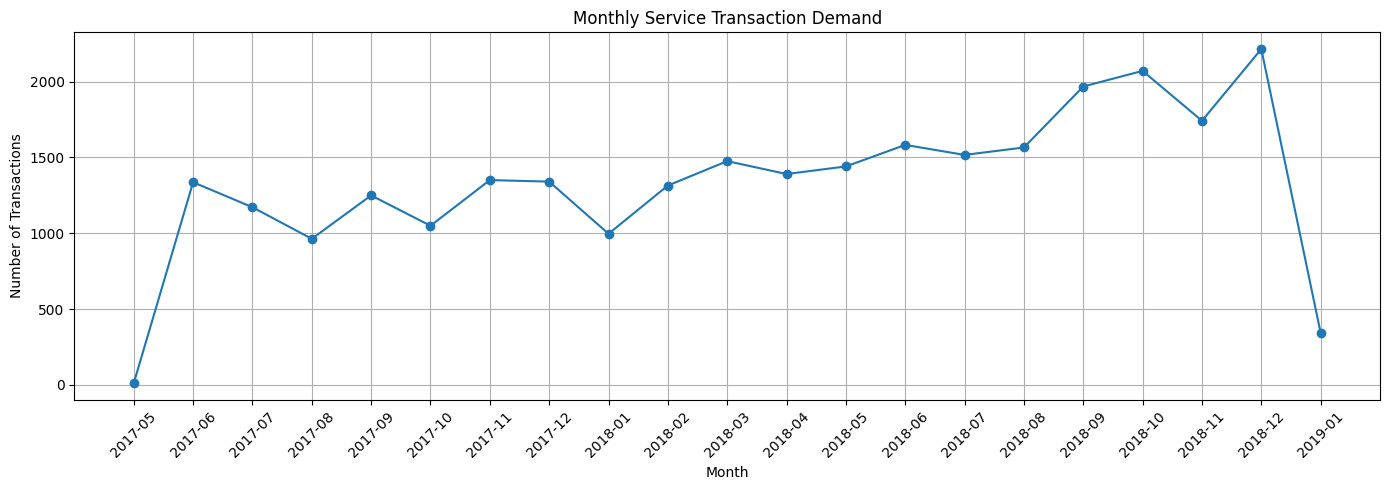

In [26]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_demand["year_month"],
    monthly_demand["demand"],
    marker="o"
)

plt.title("Monthly Service Transaction Demand")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Top 20 invoice-line items

In [27]:
top_items = (df_clean["invoice_line_text"].value_counts().head(20).reset_index())

top_items.columns = ["invoice_line_text","demand"]

display(top_items)

,invoice_line_text,demand
0,ENGINE OIL,3780
1,CHAIN LUBRICATION,3417
2,GENERAL SERVICE,2132
3,AIR FILTER,1698
4,3M OIL,1615
5,CONSUMABLES,1582
6,POLISH,1236
7,DISC OIL,985
8,BRAKE SHOE,861
9,OIL FILTER,814


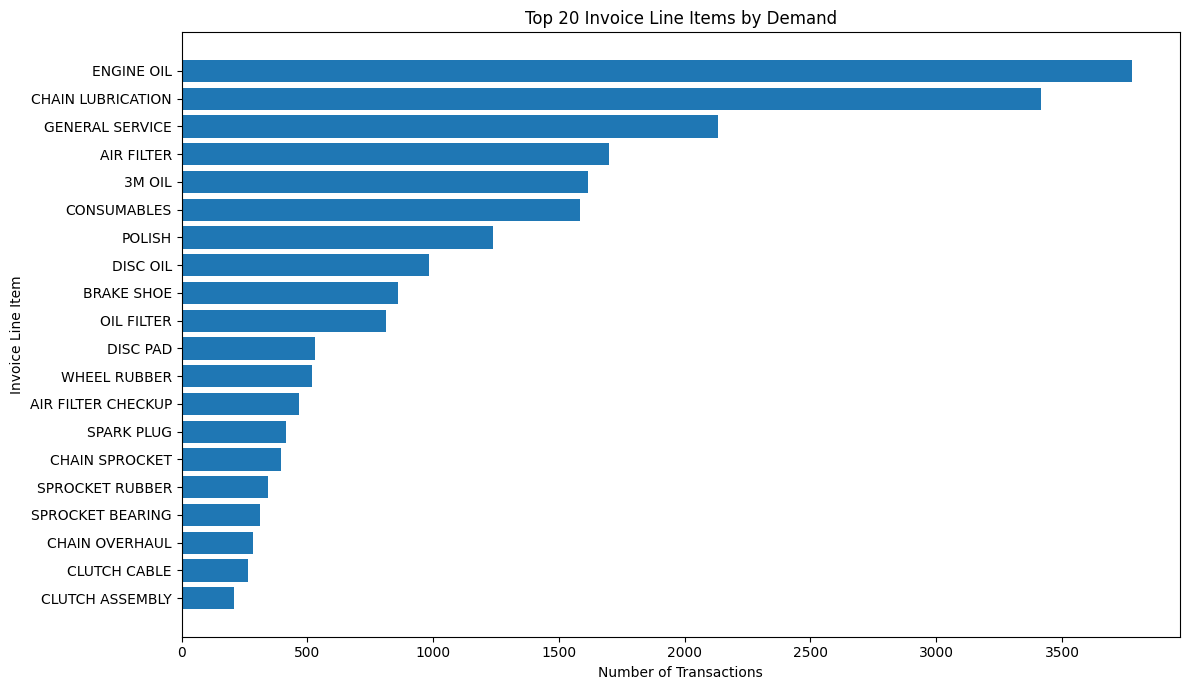

In [28]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_items["invoice_line_text"][::-1],
    top_items["demand"][::-1]
)

plt.title("Top 20 Invoice Line Items by Demand")
plt.xlabel("Number of Transactions")
plt.ylabel("Invoice Line Item")
plt.tight_layout()
plt.show()

### Monthly demand by item

In [29]:
engine_oil_monthly = (
    df_clean[
        df_clean["invoice_line_text"] == "ENGINE OIL"
    ]
    .groupby("year_month")
    .size()
    .reset_index(name="demand")
)

engine_oil_monthly["year_month"] = (
    engine_oil_monthly["year_month"].astype(str)
)

display(engine_oil_monthly)

,year_month,demand
0,2017-05,5
1,2017-06,179
2,2017-07,172
3,2017-08,145
4,2017-09,187
5,2017-10,158
6,2017-11,188
7,2017-12,212
8,2018-01,154
9,2018-02,198


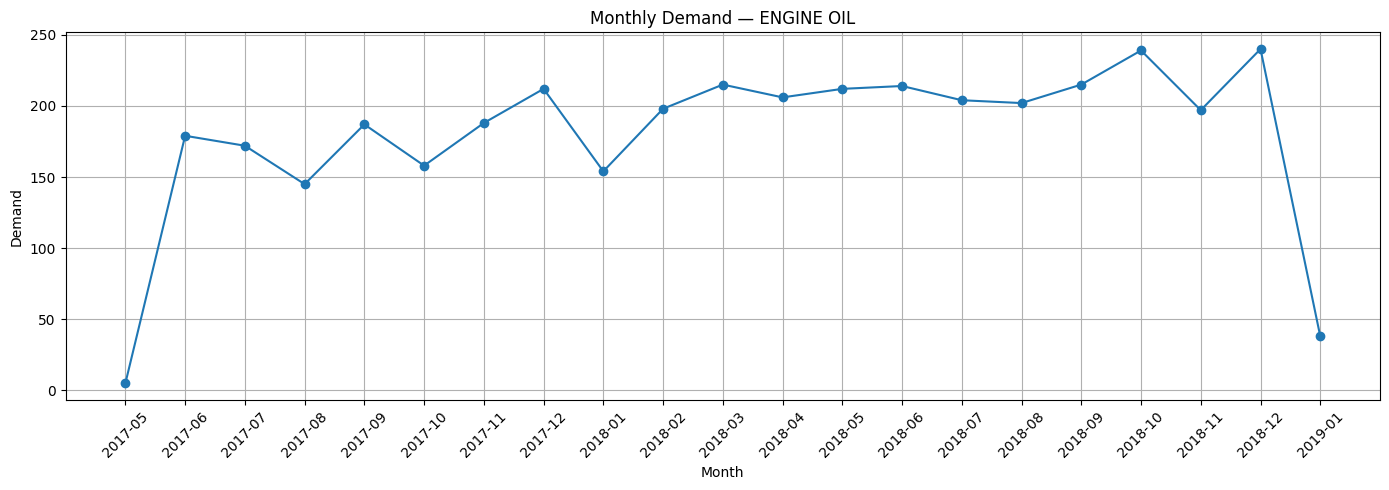

In [30]:
plt.figure(figsize=(14, 5))

plt.plot(
    engine_oil_monthly["year_month"],
    engine_oil_monthly["demand"],
    marker="o"
)

plt.title("Monthly Demand — ENGINE OIL")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Demand by vehicle model

In [31]:
vehicle_model_demand = (df_clean["vehicle_model"].value_counts().reset_index())

vehicle_model_demand.columns = ["vehicle_model","demand"]

display(vehicle_model_demand)

,vehicle_model,demand
0,BAJAJ PULSAR 150,8498
1,BAJAJ AVENGER STREET 220,4162
2,BAJAJ PULSAR 220,2607
3,BAJAJ PULSAR 180,2237
4,BAJAJ PULSAR NS 200,2179
5,BAJAJ CT 100,1401
6,BAJAJ DISCOVER 125,1339
7,BAJAJ AVENGER STREET,1103
8,BAJAJ PLATINA,829
9,BAJAJ V150,683


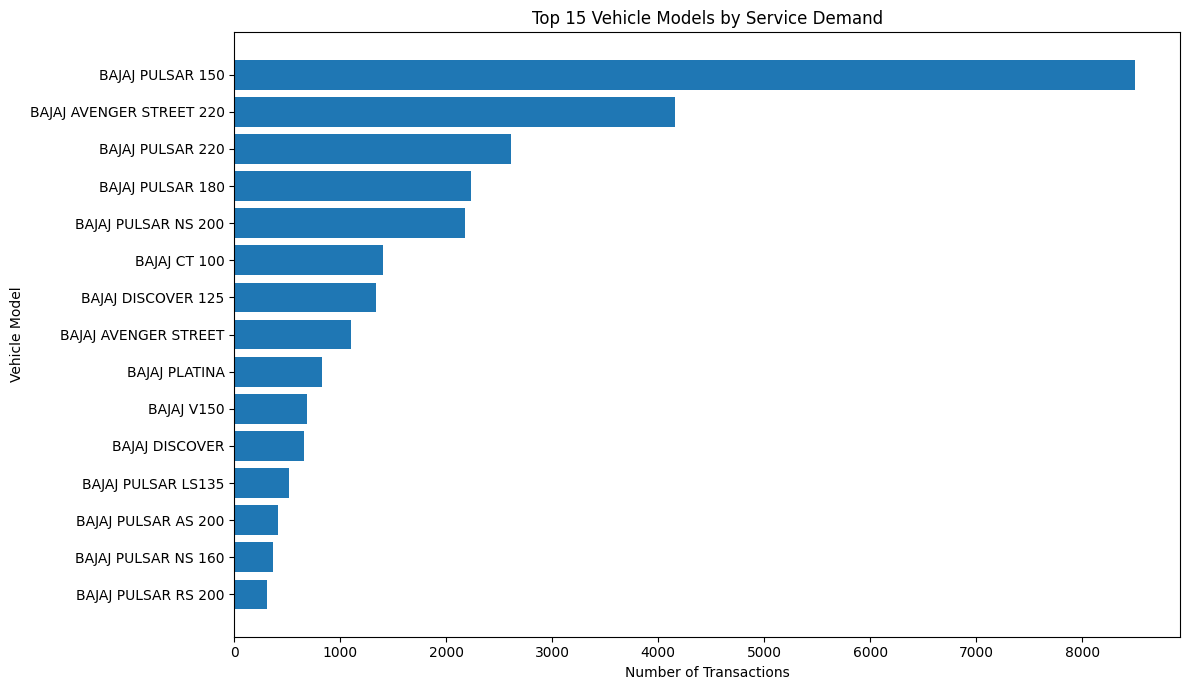

In [32]:
top_vehicle_models = vehicle_model_demand.head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_vehicle_models["vehicle_model"][::-1],
    top_vehicle_models["demand"][::-1]
)

plt.title("Top 15 Vehicle Models by Service Demand")
plt.xlabel("Number of Transactions")
plt.ylabel("Vehicle Model")
plt.tight_layout()
plt.show()

### Spare-part demand by vehicle model

In [33]:
engine_oil_vehicle = (
    df_clean[
        df_clean["invoice_line_text"] == "ENGINE OIL"
    ]["vehicle_model"]
    .value_counts()
    .head(10)
    .reset_index()
)

engine_oil_vehicle.columns = ["vehicle_model","demand"]

display(engine_oil_vehicle)

,vehicle_model,demand
0,BAJAJ PULSAR 150,1059
1,BAJAJ AVENGER STREET 220,588
2,BAJAJ PULSAR 220,335
3,BAJAJ PULSAR 180,302
4,BAJAJ PULSAR NS 200,296
5,BAJAJ CT 100,241
6,BAJAJ AVENGER STREET,171
7,BAJAJ DISCOVER 125,168
8,BAJAJ PLATINA,127
9,BAJAJ V150,97


### Monthly demand by year

In [34]:
yearly_demand = (
    df_clean
    .groupby("year")
    .size()
    .reset_index(name="demand")
)

display(yearly_demand)

,year,demand
0,2017,8469
1,2018,19270
2,2019,342


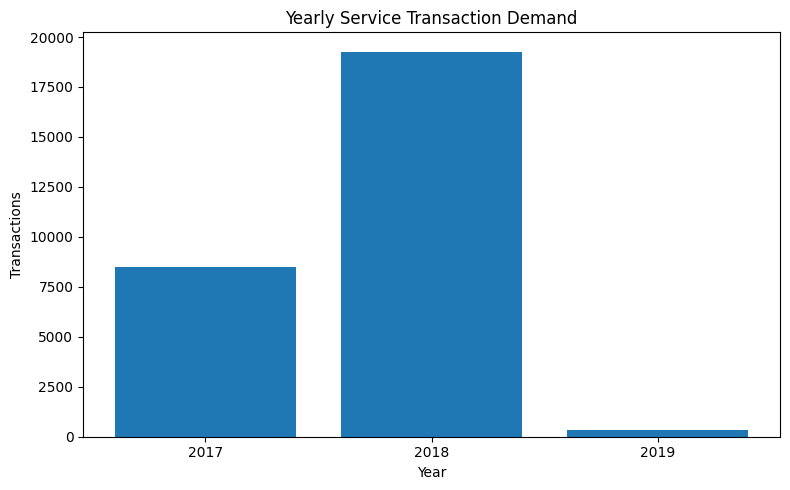

In [35]:
plt.figure(figsize=(8, 5))

plt.bar(
    yearly_demand["year"].astype(str),
    yearly_demand["demand"]
)

plt.title("Yearly Service Transaction Demand")
plt.xlabel("Year")
plt.ylabel("Transactions")
plt.tight_layout()
plt.show()

### Monthly seasonality

In [36]:
monthly_seasonality = (
    df_clean
    .groupby("month")
    .size()
    .reset_index(name="demand")
)

display(monthly_seasonality)

,month,demand
0,1,1338
1,2,1314
2,3,1475
3,4,1390
4,5,1451
5,6,2918
6,7,2687
7,8,2528
8,9,3216
9,10,3119


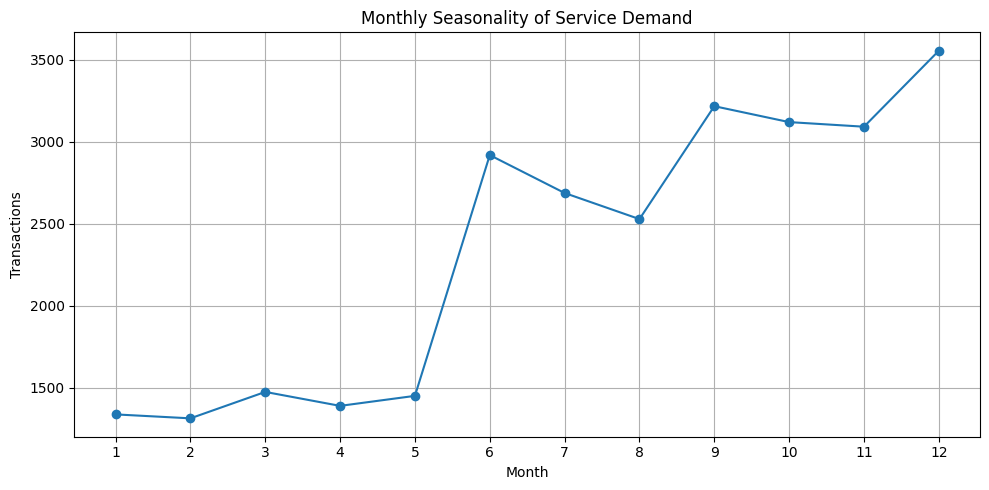

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_seasonality["month"],
    monthly_seasonality["demand"],
    marker="o"
)

plt.title("Monthly Seasonality of Service Demand")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

### Spare-part frequency distribution

In [38]:
item_frequency = (df_clean["invoice_line_text"].value_counts())

print("Total unique items:", len(item_frequency))

print("\nItems used only once:",(item_frequency == 1).sum())

print("Items used <= 5 times:",(item_frequency <= 5).sum())

print("Items used <= 10 times:",(item_frequency <= 10).sum())

print("Items used > 100 times:",(item_frequency > 100).sum())

Total unique items: 502

Items used only once: 174
Items used <= 5 times: 312
Items used <= 10 times: 361
Items used > 100 times: 29


### Create a Pareto analysis

In [39]:
pareto = (
    df_clean["invoice_line_text"]
    .value_counts()
    .reset_index()
)

pareto.columns = [
    "invoice_line_text",
    "demand"
]

pareto["cumulative_demand"] = pareto["demand"].cumsum()

pareto["cumulative_percentage"] = (
    pareto["cumulative_demand"]
    / pareto["demand"].sum()
    * 100
)

display(pareto.head(30))

,invoice_line_text,demand,cumulative_demand,cumulative_percentage
0,ENGINE OIL,3780,3780,13.461059
1,CHAIN LUBRICATION,3417,7197,25.629429
2,GENERAL SERVICE,2132,9329,33.221751
3,AIR FILTER,1698,11027,39.268545
4,3M OIL,1615,12642,45.019764
5,CONSUMABLES,1582,14224,50.653467
6,POLISH,1236,15460,55.055019
7,DISC OIL,985,16445,58.562729
8,BRAKE SHOE,861,17306,61.628859
9,OIL FILTER,814,18120,64.527617


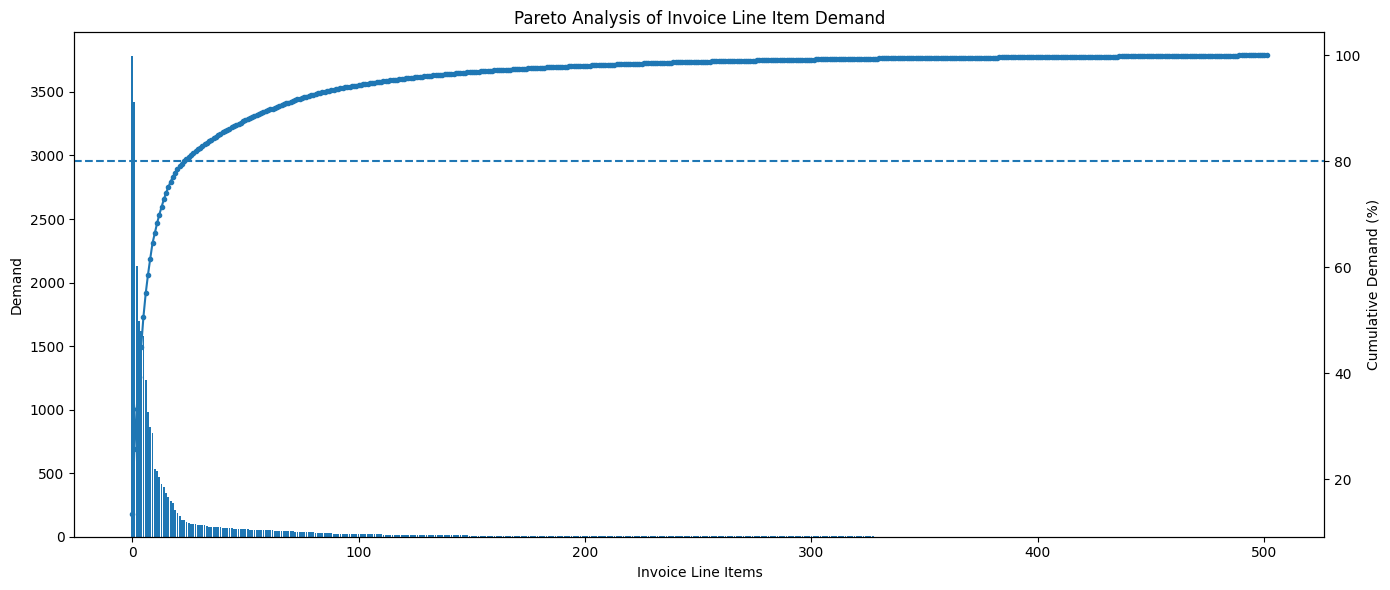

In [40]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(range(len(pareto)),pareto["demand"])

ax1.set_xlabel("Invoice Line Items")
ax1.set_ylabel("Demand")

ax2 = ax1.twinx()

ax2.plot(range(len(pareto)),pareto["cumulative_percentage"],marker=".")

ax2.set_ylabel("Cumulative Demand (%)")
ax2.axhline(80, linestyle="--")

plt.title("Pareto Analysis of Invoice Line Item Demand")
plt.tight_layout()
plt.show()

### Check demand trend for the major items

In [41]:
top_10_items = (
    df_clean["invoice_line_text"]
    .value_counts()
    .head(10)
    .index
)

top_10_monthly = (
    df_clean[
        df_clean["invoice_line_text"].isin(top_10_items)
    ]
    .groupby([
        "year_month",
        "invoice_line_text"
    ])
    .size()
    .reset_index(name="demand")
)

display(top_10_monthly.head(30))

,year_month,invoice_line_text,demand
0,2017-05,3M OIL,2
1,2017-05,CHAIN LUBRICATION,2
2,2017-05,ENGINE OIL,5
3,2017-05,GENERAL SERVICE,1
4,2017-05,OIL FILTER,1
5,2017-06,3M OIL,88
6,2017-06,AIR FILTER,5
7,2017-06,BRAKE SHOE,43
8,2017-06,CHAIN LUBRICATION,167
9,2017-06,CONSUMABLES,79


### Current KM analysis

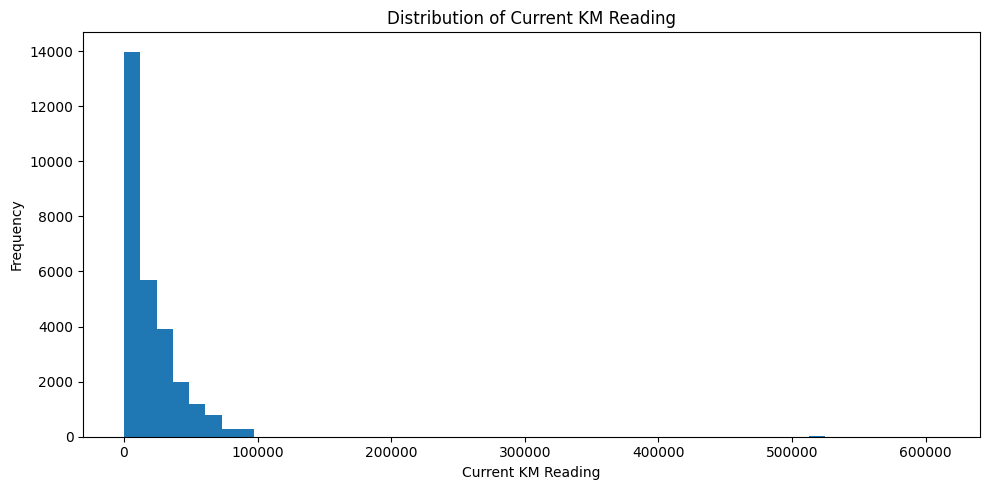

In [42]:
plt.figure(figsize=(10, 5))

plt.hist(df_clean["current_km_reading"],bins=50)

plt.title("Distribution of Current KM Reading")
plt.xlabel("Current KM Reading")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Create the Forecasting Dataset

### Select frequently occurring items

In [43]:
item_frequency = (df_clean["invoice_line_text"].value_counts())

frequent_items = item_frequency[item_frequency > 100].index

print("Number of frequent items:", len(frequent_items))

print("\nFrequent items:")
print(frequent_items.tolist())

Number of frequent items: 29

Frequent items:
['ENGINE OIL', 'CHAIN LUBRICATION', 'GENERAL SERVICE', 'AIR FILTER', '3M OIL', 'CONSUMABLES', 'POLISH', 'DISC OIL', 'BRAKE SHOE', 'OIL FILTER', 'DISC PAD', 'WHEEL RUBBER', 'AIR FILTER CHECKUP', 'SPARK PLUG', 'CHAIN SPROCKET', 'SPROCKET RUBBER', 'SPROCKET BEARING', 'CHAIN OVERHAUL', 'CLUTCH CABLE', 'CLUTCH ASSEMBLY', 'CLUTCH COVER GASKET', 'CLUTCH OVERHUAL', 'TANK COVER', 'LABOUR', 'SEAT COVER', 'INDICATOR', 'DISC PUMP KIT', 'DRUM BOLT', 'TAIL LAMP BULB']


### Spare parts selected for forecasting

In [44]:

spare_parts = [
    'AIR FILTER',
    'BRAKE SHOE',
    'OIL FILTER',
    'DISC PAD',
    'WHEEL RUBBER',
    'SPARK PLUG',
    'CHAIN SPROCKET',
    'SPROCKET RUBBER',
    'SPROCKET BEARING',
    'CLUTCH CABLE',
    'CLUTCH ASSEMBLY',
    'CLUTCH COVER GASKET',
    'TANK COVER',
    'SEAT COVER',
    'INDICATOR',
    'DISC PUMP KIT',
    'DRUM BOLT',
    'TAIL LAMP BULB'
]

print("Number of spare parts:", len(spare_parts))
print("\nSpare parts:")
for i, item in enumerate(spare_parts, start=1):
    print(f"{i:2}. {item}")

Number of spare parts: 18

Spare parts:
 1. AIR FILTER
 2. BRAKE SHOE
 3. OIL FILTER
 4. DISC PAD
 5. WHEEL RUBBER
 6. SPARK PLUG
 7. CHAIN SPROCKET
 8. SPROCKET RUBBER
 9. SPROCKET BEARING
10. CLUTCH CABLE
11. CLUTCH ASSEMBLY
12. CLUTCH COVER GASKET
13. TANK COVER
14. SEAT COVER
15. INDICATOR
16. DISC PUMP KIT
17. DRUM BOLT
18. TAIL LAMP BULB


In [45]:
df_forecast = df_clean[df_clean["invoice_line_text"].isin(spare_parts)].copy()

print("Forecasting dataset shape:", df_forecast.shape)

df_forecast.head()

Forecasting dataset shape: (7208, 14)


,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text,year,month,month_name,year_month,day,day_of_week,week
12,2017-05-31,2017-05-31,diliXXXXXXXXXX,KA53S3XXXX,BAJAJ V,7854,OIL FILTER,2017,5,May,2017-05,31,Wednesday,22
17,2017-06-03,2017-05-31,MAYAXXXXXXXXXX,KA05JGXXXX,BAJAJ PULSAR 220,25000,INDICATOR,2017,6,June,2017-06,3,Saturday,22
24,2017-06-03,2017-05-31,MAYAXXXXXXXXXX,KA05JGXXXX,BAJAJ PULSAR 220,25000,DISC PAD,2017,6,June,2017-06,3,Saturday,22
31,2017-06-03,2017-05-31,MAYAXXXXXXXXXX,KA05JGXXXX,BAJAJ PULSAR 220,25000,CLUTCH ASSEMBLY,2017,6,June,2017-06,3,Saturday,22
33,2017-06-03,2017-05-31,MAYAXXXXXXXXXX,KA05JGXXXX,BAJAJ PULSAR 220,25000,SPARK PLUG,2017,6,June,2017-06,3,Saturday,22


In [46]:
part_counts = (
    df_forecast["invoice_line_text"]
    .value_counts()
    .reset_index()
)

part_counts.columns = ["spare_part", "demand_count"]

part_counts

,spare_part,demand_count
0,AIR FILTER,1698
1,BRAKE SHOE,861
2,OIL FILTER,814
3,DISC PAD,530
4,WHEEL RUBBER,518
5,SPARK PLUG,414
6,CHAIN SPROCKET,394
7,SPROCKET RUBBER,344
8,SPROCKET BEARING,311
9,CLUTCH CABLE,262


### Create monthly demand

In [47]:
df_forecast["year_month"] = (
    df_forecast["invoice_date"]
    .dt.to_period("M")
)

In [48]:
monthly_demand = (
    df_forecast
    .groupby(["year_month", "invoice_line_text"])
    .size()
    .reset_index(name="demand")
)

monthly_demand.head(20)

,year_month,invoice_line_text,demand
0,2017-05,OIL FILTER,1
1,2017-06,AIR FILTER,5
2,2017-06,BRAKE SHOE,43
3,2017-06,CHAIN SPROCKET,9
4,2017-06,CLUTCH ASSEMBLY,10
5,2017-06,CLUTCH CABLE,3
6,2017-06,CLUTCH COVER GASKET,6
7,2017-06,DISC PAD,24
8,2017-06,DISC PUMP KIT,3
9,2017-06,DRUM BOLT,2


### Convert to time-series format

In [49]:
all_months = pd.period_range(
    start=df_clean["invoice_date"].min().to_period("M"),
    end=df_clean["invoice_date"].max().to_period("M"),
    freq="M"
)

all_months

PeriodIndex(['2017-05', '2017-06', '2017-07', '2017-08', '2017-09', '2017-10',
             '2017-11', '2017-12', '2018-01', '2018-02', '2018-03', '2018-04',
             '2018-05', '2018-06', '2018-07', '2018-08', '2018-09', '2018-10',
             '2018-11', '2018-12', '2019-01'],
            dtype='period[M]')

In [50]:
complete_index = pd.MultiIndex.from_product(
    [all_months, spare_parts],
    names=["year_month", "invoice_line_text"]
)

monthly_demand_complete = (
    monthly_demand
    .set_index(["year_month", "invoice_line_text"])
    .reindex(complete_index, fill_value=0)
    .reset_index()
)

monthly_demand_complete.head(20)

,year_month,invoice_line_text,demand
0,2017-05,AIR FILTER,0
1,2017-05,BRAKE SHOE,0
2,2017-05,OIL FILTER,1
3,2017-05,DISC PAD,0
4,2017-05,WHEEL RUBBER,0
5,2017-05,SPARK PLUG,0
6,2017-05,CHAIN SPROCKET,0
7,2017-05,SPROCKET RUBBER,0
8,2017-05,SPROCKET BEARING,0
9,2017-05,CLUTCH CABLE,0


In [51]:
print("Monthly forecasting dataset shape:")
print(monthly_demand_complete.shape)

Monthly forecasting dataset shape:
(378, 3)


### Create the final pivot table

In [52]:
monthly_demand_pivot = (
    monthly_demand_complete
    .pivot(
        index="year_month",
        columns="invoice_line_text",
        values="demand"
    )
    .reset_index()
)

monthly_demand_pivot

invoice_line_text,year_month,AIR FILTER,BRAKE SHOE,CHAIN SPROCKET,CLUTCH ASSEMBLY,CLUTCH CABLE,CLUTCH COVER GASKET,DISC PAD,DISC PUMP KIT,DRUM BOLT,INDICATOR,OIL FILTER,SEAT COVER,SPARK PLUG,SPROCKET BEARING,SPROCKET RUBBER,TAIL LAMP BULB,TANK COVER,WHEEL RUBBER
0,2017-05,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,2017-06,5,43,9,10,3,6,24,3,2,8,34,5,9,1,0,8,7,34
2,2017-07,34,33,19,6,0,7,25,4,3,10,21,5,11,1,0,4,4,31
3,2017-08,49,29,15,9,1,6,19,4,0,6,28,4,9,0,0,1,8,16
4,2017-09,76,36,11,11,0,9,19,4,1,10,25,4,18,0,0,0,8,25
5,2017-10,70,41,19,8,7,7,13,5,0,4,27,4,8,0,0,8,4,19
6,2017-11,88,50,17,8,14,5,31,5,4,8,25,4,14,2,0,7,7,29
7,2017-12,112,47,14,10,17,8,31,4,3,7,32,8,6,0,0,7,8,43
8,2018-01,77,38,18,3,6,2,24,0,3,3,22,7,8,1,0,2,2,26
9,2018-02,86,47,26,5,11,7,32,3,4,3,32,6,9,1,0,5,5,34


In [53]:
monthly_demand_pivot.to_csv("spare_parts_monthly_demand.csv",index=False)

print("Forecasting dataset saved successfully.")

Forecasting dataset saved successfully.


In [54]:
print("29 frequent categories:\n")

for i, item in enumerate(frequent_items, start=1):
    print(f"{i:2}. {item}")

29 frequent categories:

 1. ENGINE OIL
 2. CHAIN LUBRICATION
 3. GENERAL SERVICE
 4. AIR FILTER
 5. 3M OIL
 6. CONSUMABLES
 7. POLISH
 8. DISC OIL
 9. BRAKE SHOE
10. OIL FILTER
11. DISC PAD
12. WHEEL RUBBER
13. AIR FILTER CHECKUP
14. SPARK PLUG
15. CHAIN SPROCKET
16. SPROCKET RUBBER
17. SPROCKET BEARING
18. CHAIN OVERHAUL
19. CLUTCH CABLE
20. CLUTCH ASSEMBLY
21. CLUTCH COVER GASKET
22. CLUTCH OVERHUAL
23. TANK COVER
24. LABOUR
25. SEAT COVER
26. INDICATOR
27. DISC PUMP KIT
28. DRUM BOLT
29. TAIL LAMP BULB


# Spare-Part Demand Analysis

### Check monthly demand statistics

In [55]:
demand_stats = (
    monthly_demand_complete
    .groupby("invoice_line_text")["demand"]
    .agg(
        total_demand="sum",
        average_monthly_demand="mean",
        median_monthly_demand="median",
        std_monthly_demand="std",
        min_monthly_demand="min",
        max_monthly_demand="max",
        zero_demand_months=lambda x: (x == 0).sum()
    )
    .sort_values("total_demand", ascending=False)
)

demand_stats

,total_demand,average_monthly_demand,median_monthly_demand,std_monthly_demand,min_monthly_demand,max_monthly_demand,zero_demand_months
invoice_line_text,,,,,,,
AIR FILTER,1698,80.857143,86.0,41.439457,0,145,1
BRAKE SHOE,861,41.000000,44.0,14.659468,0,56,1
OIL FILTER,814,38.761905,34.0,18.630364,1,68,0
DISC PAD,530,25.238095,24.0,10.695348,0,45,1
WHEEL RUBBER,518,24.666667,25.0,15.031079,0,53,2
SPARK PLUG,414,19.714286,11.0,17.507549,0,61,1
CHAIN SPROCKET,394,18.761905,19.0,8.814220,0,38,1
SPROCKET RUBBER,344,16.380952,0.0,33.465618,0,113,13
SPROCKET BEARING,311,14.809524,1.0,28.732593,0,90,8


### Calculate demand variability

In [56]:
demand_stats["cv"] = (
    demand_stats["std_monthly_demand"] /
    demand_stats["average_monthly_demand"]
)

demand_stats

,total_demand,average_monthly_demand,median_monthly_demand,std_monthly_demand,min_monthly_demand,max_monthly_demand,zero_demand_months,cv
invoice_line_text,,,,,,,,
AIR FILTER,1698,80.857143,86.0,41.439457,0,145,1,0.512502
BRAKE SHOE,861,41.000000,44.0,14.659468,0,56,1,0.357548
OIL FILTER,814,38.761905,34.0,18.630364,1,68,0,0.480636
DISC PAD,530,25.238095,24.0,10.695348,0,45,1,0.423778
WHEEL RUBBER,518,24.666667,25.0,15.031079,0,53,2,0.609368
SPARK PLUG,414,19.714286,11.0,17.507549,0,61,1,0.888064
CHAIN SPROCKET,394,18.761905,19.0,8.814220,0,38,1,0.469793
SPROCKET RUBBER,344,16.380952,0.0,33.465618,0,113,13,2.042959
SPROCKET BEARING,311,14.809524,1.0,28.732593,0,90,8,1.940143


### Check zero-demand months

In [57]:
zero_month_analysis = (
    monthly_demand_complete
    .groupby("invoice_line_text")["demand"]
    .apply(lambda x: (x == 0).sum())
    .sort_values(ascending=False)
)

zero_month_analysis

invoice_line_text
SPROCKET RUBBER        13
SPROCKET BEARING        8
DRUM BOLT               4
CLUTCH CABLE            3
DISC PUMP KIT           3
TAIL LAMP BULB          2
SEAT COVER              2
WHEEL RUBBER            2
BRAKE SHOE              1
AIR FILTER              1
INDICATOR               1
DISC PAD                1
CLUTCH ASSEMBLY         1
CLUTCH COVER GASKET     1
CHAIN SPROCKET          1
SPARK PLUG              1
TANK COVER              1
OIL FILTER              0
Name: demand, dtype: int64

### Visualize total demand

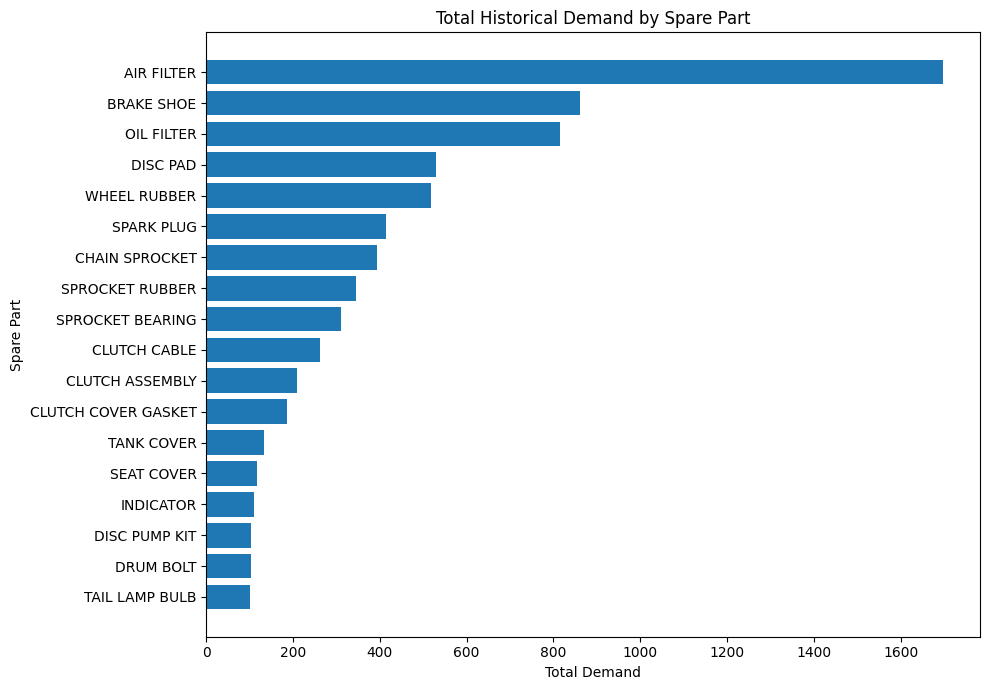

In [58]:
import matplotlib.pyplot as plt

plot_data = (
    demand_stats
    .sort_values("total_demand", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data.index,
    plot_data["total_demand"]
)

plt.xlabel("Total Demand")
plt.ylabel("Spare Part")
plt.title("Total Historical Demand by Spare Part")

plt.tight_layout()
plt.show()

### Analyze monthly demand trends

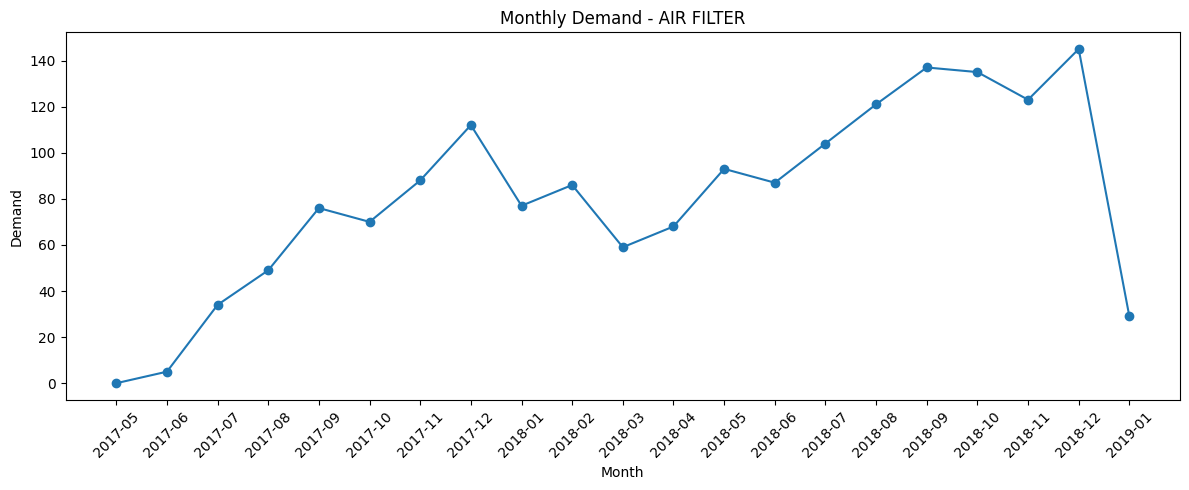

In [59]:
part = "AIR FILTER"

part_data = monthly_demand_complete[
    monthly_demand_complete["invoice_line_text"] == part
]

plt.figure(figsize=(12, 5))

plt.plot(
    part_data["year_month"].astype(str),
    part_data["demand"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Demand")
plt.title(f"Monthly Demand - {part}")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

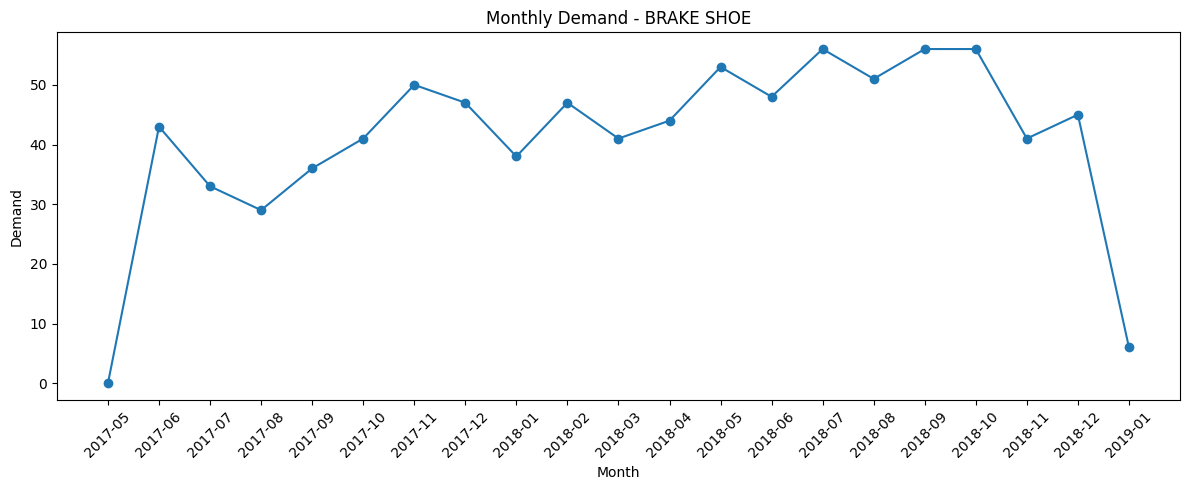

In [60]:
part = "BRAKE SHOE"

part_data = monthly_demand_complete[
    monthly_demand_complete["invoice_line_text"] == part
]

plt.figure(figsize=(12, 5))

plt.plot(
    part_data["year_month"].astype(str),
    part_data["demand"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Demand")
plt.title(f"Monthly Demand - {part}")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [61]:
def plot_part_demand(part_name):

    part_data = monthly_demand_complete[
        monthly_demand_complete["invoice_line_text"] == part_name
    ]

    plt.figure(figsize=(12, 5))

    plt.plot(
        part_data["year_month"].astype(str),
        part_data["demand"],
        marker="o"
    )

    plt.xlabel("Month")
    plt.ylabel("Demand")
    plt.title(f"Monthly Demand - {part_name}")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

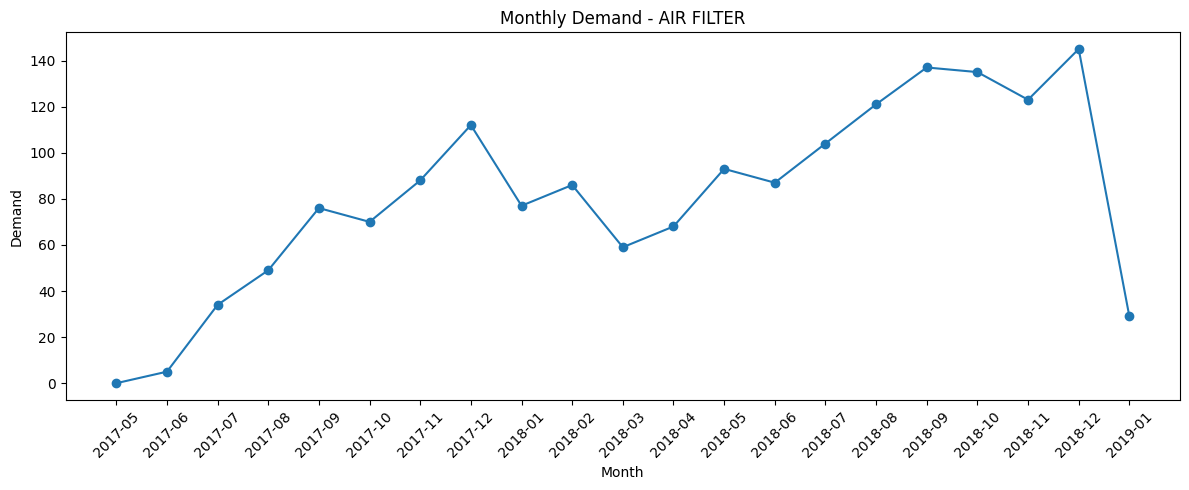

In [62]:
plot_part_demand("AIR FILTER")

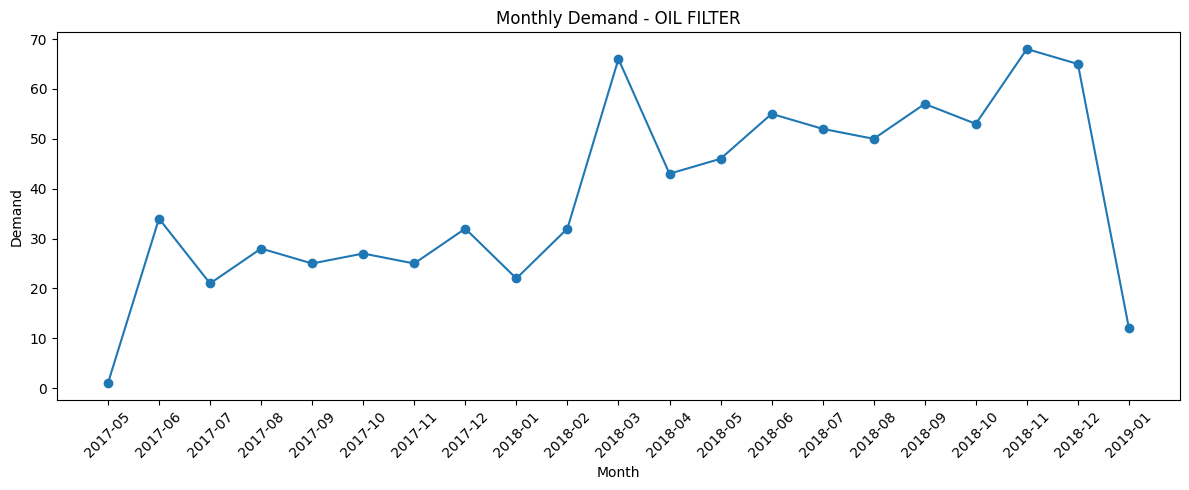

In [63]:
plot_part_demand("OIL FILTER")

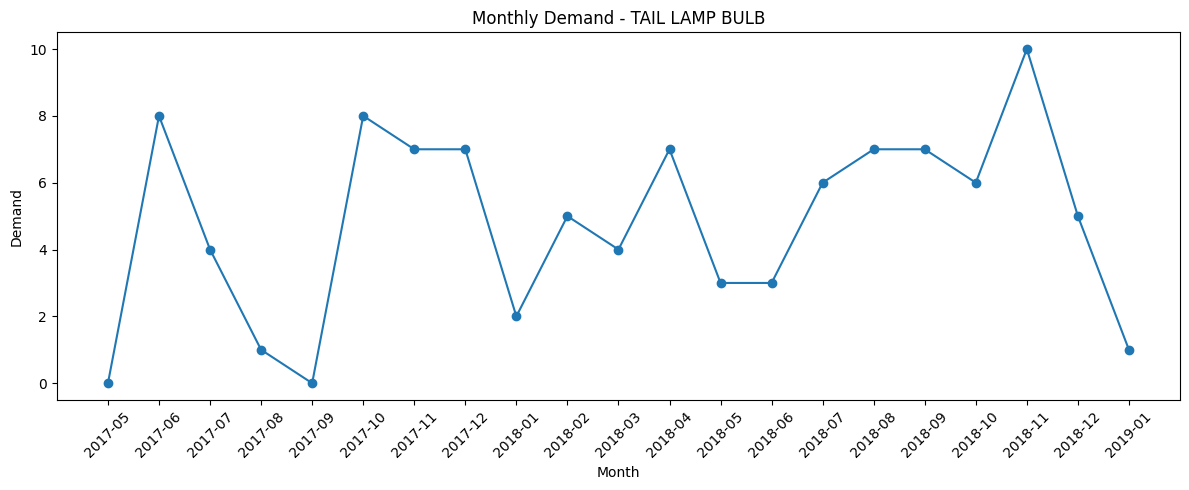

In [64]:
plot_part_demand("TAIL LAMP BULB")

In [65]:
steps_summary = demand_stats[
    [
        "total_demand",
        "average_monthly_demand",
        "median_monthly_demand",
        "std_monthly_demand",
        "min_monthly_demand",
        "max_monthly_demand",
        "zero_demand_months",
        "cv"
    ]
].copy()

steps_summary

,total_demand,average_monthly_demand,median_monthly_demand,std_monthly_demand,min_monthly_demand,max_monthly_demand,zero_demand_months,cv
invoice_line_text,,,,,,,,
AIR FILTER,1698,80.857143,86.0,41.439457,0,145,1,0.512502
BRAKE SHOE,861,41.000000,44.0,14.659468,0,56,1,0.357548
OIL FILTER,814,38.761905,34.0,18.630364,1,68,0,0.480636
DISC PAD,530,25.238095,24.0,10.695348,0,45,1,0.423778
WHEEL RUBBER,518,24.666667,25.0,15.031079,0,53,2,0.609368
SPARK PLUG,414,19.714286,11.0,17.507549,0,61,1,0.888064
CHAIN SPROCKET,394,18.761905,19.0,8.814220,0,38,1,0.469793
SPROCKET RUBBER,344,16.380952,0.0,33.465618,0,113,13,2.042959
SPROCKET BEARING,311,14.809524,1.0,28.732593,0,90,8,1.940143


In [67]:
steps_summary = steps_summary.round(2)

steps_summary

,total_demand,average_monthly_demand,median_monthly_demand,std_monthly_demand,min_monthly_demand,max_monthly_demand,zero_demand_months,cv
invoice_line_text,,,,,,,,
AIR FILTER,1698,80.86,86.0,41.44,0,145,1,0.51
BRAKE SHOE,861,41.00,44.0,14.66,0,56,1,0.36
OIL FILTER,814,38.76,34.0,18.63,1,68,0,0.48
DISC PAD,530,25.24,24.0,10.70,0,45,1,0.42
WHEEL RUBBER,518,24.67,25.0,15.03,0,53,2,0.61
SPARK PLUG,414,19.71,11.0,17.51,0,61,1,0.89
CHAIN SPROCKET,394,18.76,19.0,8.81,0,38,1,0.47
SPROCKET RUBBER,344,16.38,0.0,33.47,0,113,13,2.04
SPROCKET BEARING,311,14.81,1.0,28.73,0,90,8,1.94


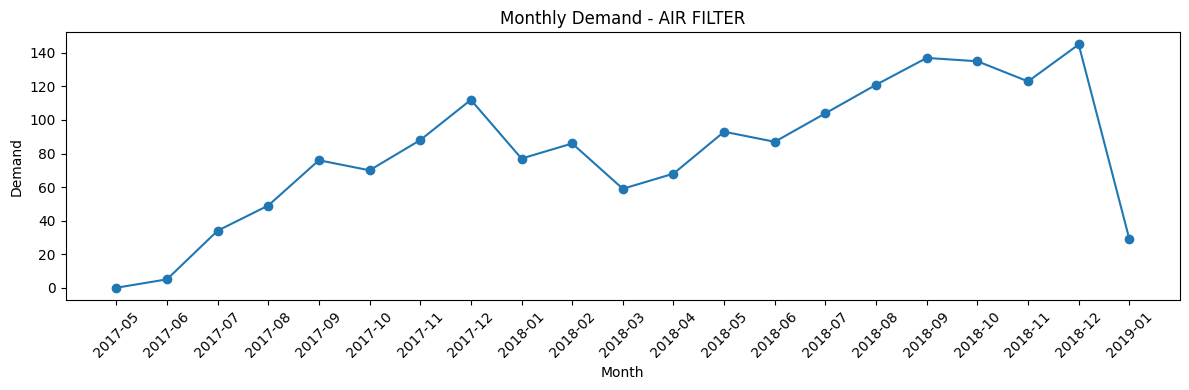

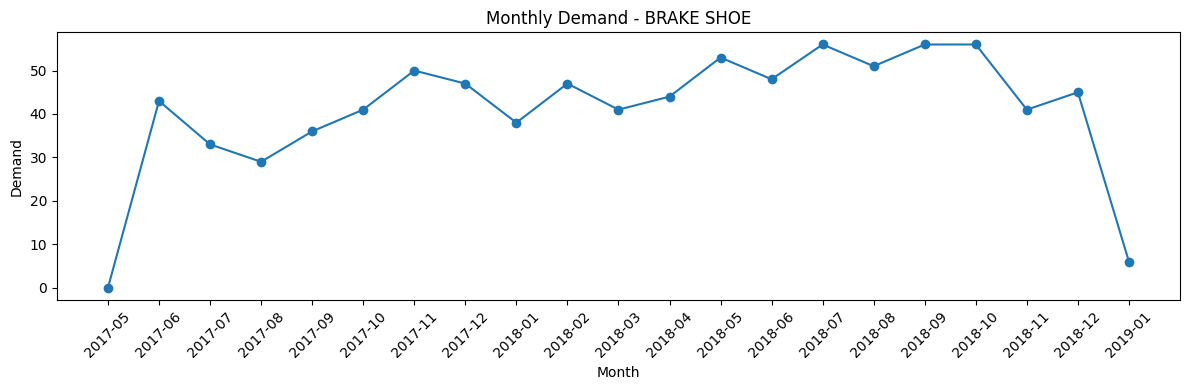

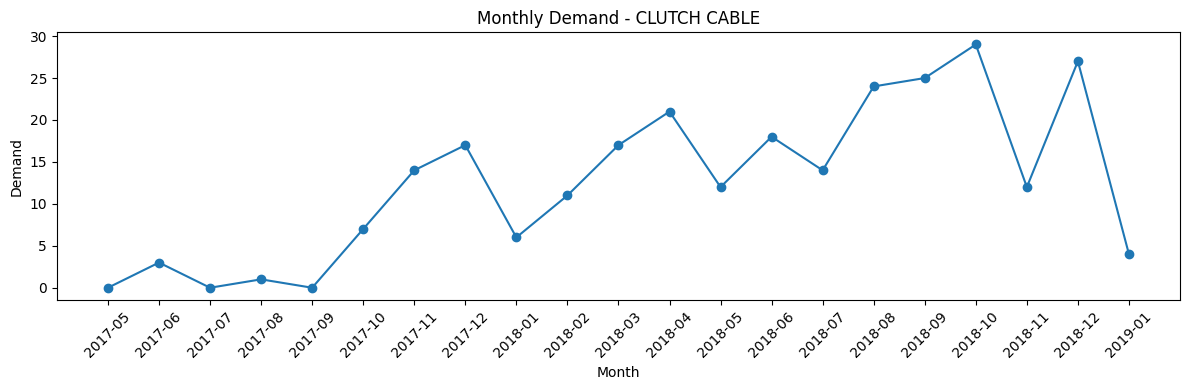

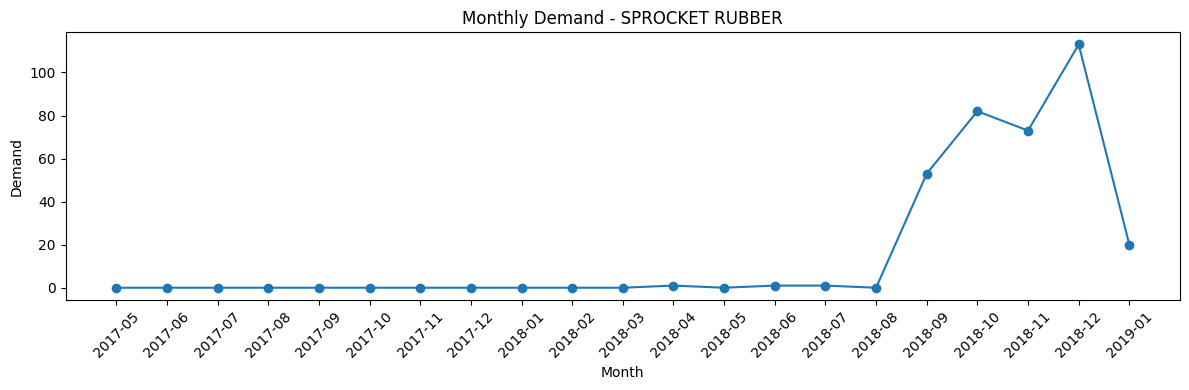

In [68]:
selected_parts = [
    "AIR FILTER",
    "BRAKE SHOE",
    "CLUTCH CABLE",
    "SPROCKET RUBBER"
]

for part in selected_parts:

    part_data = monthly_demand_complete[
        monthly_demand_complete["invoice_line_text"] == part
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        part_data["year_month"].astype(str),
        part_data["demand"],
        marker="o"
    )

    plt.xlabel("Month")
    plt.ylabel("Demand")
    plt.title(f"Monthly Demand - {part}")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [69]:
def classify_demand(row):

    if row["zero_demand_months"] >= 8 or row["cv"] >= 1.5:
        return "Intermittent / Highly Variable"

    elif row["cv"] >= 0.5:
        return "Moderately Variable"

    else:
        return "Relatively Stable"


steps_summary["demand_pattern"] = steps_summary.apply(
    classify_demand,
    axis=1
)

steps_summary

,total_demand,average_monthly_demand,median_monthly_demand,std_monthly_demand,min_monthly_demand,max_monthly_demand,zero_demand_months,cv,demand_pattern
invoice_line_text,,,,,,,,,
AIR FILTER,1698,80.86,86.0,41.44,0,145,1,0.51,Moderately Variable
BRAKE SHOE,861,41.00,44.0,14.66,0,56,1,0.36,Relatively Stable
OIL FILTER,814,38.76,34.0,18.63,1,68,0,0.48,Relatively Stable
DISC PAD,530,25.24,24.0,10.70,0,45,1,0.42,Relatively Stable
WHEEL RUBBER,518,24.67,25.0,15.03,0,53,2,0.61,Moderately Variable
SPARK PLUG,414,19.71,11.0,17.51,0,61,1,0.89,Moderately Variable
CHAIN SPROCKET,394,18.76,19.0,8.81,0,38,1,0.47,Relatively Stable
SPROCKET RUBBER,344,16.38,0.0,33.47,0,113,13,2.04,Intermittent / Highly Variable
SPROCKET BEARING,311,14.81,1.0,28.73,0,90,8,1.94,Intermittent / Highly Variable


In [70]:
steps_summary[
    [
        "total_demand",
        "average_monthly_demand",
        "cv",
        "zero_demand_months",
        "demand_pattern"
    ]
]

,total_demand,average_monthly_demand,cv,zero_demand_months,demand_pattern
invoice_line_text,,,,,
AIR FILTER,1698,80.86,0.51,1,Moderately Variable
BRAKE SHOE,861,41.00,0.36,1,Relatively Stable
OIL FILTER,814,38.76,0.48,0,Relatively Stable
DISC PAD,530,25.24,0.42,1,Relatively Stable
WHEEL RUBBER,518,24.67,0.61,2,Moderately Variable
SPARK PLUG,414,19.71,0.89,1,Moderately Variable
CHAIN SPROCKET,394,18.76,0.47,1,Relatively Stable
SPROCKET RUBBER,344,16.38,2.04,13,Intermittent / Highly Variable
SPROCKET BEARING,311,14.81,1.94,8,Intermittent / Highly Variable


# Machine Learning Forecasting

In [71]:
model_data = monthly_demand_complete[
    (monthly_demand_complete["year_month"] >= "2017-06") &
    (monthly_demand_complete["year_month"] <= "2018-12")
].copy()

print("Modeling dataset shape:", model_data.shape)

model_data.head()

Modeling dataset shape: (342, 3)


,year_month,invoice_line_text,demand
18,2017-06,AIR FILTER,5
19,2017-06,BRAKE SHOE,43
20,2017-06,OIL FILTER,34
21,2017-06,DISC PAD,24
22,2017-06,WHEEL RUBBER,34


In [72]:
train_data = model_data[model_data["year_month"] <= "2018-09"].copy()

test_data = model_data[model_data["year_month"] >= "2018-10"].copy()

print("Training period:")
print(train_data["year_month"].min(), "to", train_data["year_month"].max())

print("\nTesting period:")
print(test_data["year_month"].min(), "to", test_data["year_month"].max())

print("\nTraining rows:", len(train_data))
print("Testing rows:", len(test_data))

Training period:
2017-06 to 2018-09

Testing period:
2018-10 to 2018-12

Training rows: 288
Testing rows: 54


# Build the Naive Forecast Baseline

In [73]:
# Create a table containing monthly demand for each spare part
forecast_results = []

for part in spare_parts:

    part_data = model_data[
        model_data["invoice_line_text"] == part
    ].sort_values("year_month").copy()

    # Training data
    train_part = part_data[
        part_data["year_month"] <= "2018-09"
    ].copy()

    # Test data
    test_part = part_data[
        part_data["year_month"] >= "2018-10"
    ].copy()

    # Naive forecast:
    # October forecast uses September actual,
    # November forecast uses October actual,
    # December forecast uses November actual.
    test_part["naive_forecast"] = (
        test_part["demand"].shift(1)
    )

    # First test prediction needs the last training observation
    test_part.iloc[0, test_part.columns.get_loc("naive_forecast")] = (
        train_part["demand"].iloc[-1]
    )

    test_part["spare_part"] = part

    forecast_results.append(test_part)

naive_results = pd.concat(
    forecast_results,
    ignore_index=True
)

naive_results.head(20)

,year_month,invoice_line_text,demand,naive_forecast,spare_part
0,2018-10,AIR FILTER,135,137.0,AIR FILTER
1,2018-11,AIR FILTER,123,135.0,AIR FILTER
2,2018-12,AIR FILTER,145,123.0,AIR FILTER
3,2018-10,BRAKE SHOE,56,56.0,BRAKE SHOE
4,2018-11,BRAKE SHOE,41,56.0,BRAKE SHOE
5,2018-12,BRAKE SHOE,45,41.0,BRAKE SHOE
6,2018-10,OIL FILTER,53,57.0,OIL FILTER
7,2018-11,OIL FILTER,68,53.0,OIL FILTER
8,2018-12,OIL FILTER,65,68.0,OIL FILTER
9,2018-10,DISC PAD,45,40.0,DISC PAD


In [74]:
naive_results[
    [
        "year_month",
        "spare_part",
        "demand",
        "naive_forecast"
    ]
].head(30)

,year_month,spare_part,demand,naive_forecast
0,2018-10,AIR FILTER,135,137.0
1,2018-11,AIR FILTER,123,135.0
2,2018-12,AIR FILTER,145,123.0
3,2018-10,BRAKE SHOE,56,56.0
4,2018-11,BRAKE SHOE,41,56.0
5,2018-12,BRAKE SHOE,45,41.0
6,2018-10,OIL FILTER,53,57.0
7,2018-11,OIL FILTER,68,53.0
8,2018-12,OIL FILTER,65,68.0
9,2018-10,DISC PAD,45,40.0


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

naive_metrics = []

for part in spare_parts:

    part_result = naive_results[naive_results["spare_part"] == part]

    y_true = part_result["demand"]
    y_pred = part_result["naive_forecast"]

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    naive_metrics.append({
        "spare_part": part,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

naive_metrics_df = pd.DataFrame(naive_metrics)

naive_metrics_df

,spare_part,MAE,RMSE,R2
0,AIR FILTER,12.000000,14.514361,-1.604396
1,BRAKE SHOE,6.333333,8.962886,-0.997238
2,OIL FILTER,7.333333,9.128709,-0.984127
3,DISC PAD,13.666667,16.031220,-1.455414
4,WHEEL RUBBER,10.666667,13.241349,-10.776119
5,SPARK PLUG,13.333333,19.373521,-0.504007
6,CHAIN SPROCKET,13.666667,14.548769,-2.164452
7,SPROCKET RUBBER,26.000000,28.994252,-1.863740
8,SPROCKET BEARING,11.000000,12.871156,-0.127837
9,CLUTCH CABLE,12.000000,13.291601,-2.069498


In [76]:
naive_metrics_df[
    ["MAE", "RMSE", "R2"]
] = naive_metrics_df[
    ["MAE", "RMSE", "R2"]
].round(3)

naive_metrics_df

,spare_part,MAE,RMSE,R2
0,AIR FILTER,12.000,14.514,-1.604
1,BRAKE SHOE,6.333,8.963,-0.997
2,OIL FILTER,7.333,9.129,-0.984
3,DISC PAD,13.667,16.031,-1.455
4,WHEEL RUBBER,10.667,13.241,-10.776
5,SPARK PLUG,13.333,19.374,-0.504
6,CHAIN SPROCKET,13.667,14.549,-2.164
7,SPROCKET RUBBER,26.000,28.994,-1.864
8,SPROCKET BEARING,11.000,12.871,-0.128
9,CLUTCH CABLE,12.000,13.292,-2.069


In [77]:
overall_mae = mean_absolute_error(
    naive_results["demand"],
    naive_results["naive_forecast"]
)

overall_rmse = np.sqrt(
    mean_squared_error(
        naive_results["demand"],
        naive_results["naive_forecast"]
    )
)

overall_r2 = r2_score(
    naive_results["demand"],
    naive_results["naive_forecast"]
)

print("Overall Naive Forecast Performance")
print("----------------------------------")
print(f"MAE  : {overall_mae:.3f}")
print(f"RMSE : {overall_rmse:.3f}")
print(f"R²   : {overall_r2:.3f}")

Overall Naive Forecast Performance
----------------------------------
MAE  : 8.704
RMSE : 12.442
R²   : 0.875


### Create 3-month Moving Average Forecast

In [78]:
moving_average_results = []

for part in spare_parts:

    part_data = model_data[
        model_data["invoice_line_text"] == part
    ].sort_values("year_month").copy()

    # Calculate 3-month rolling average
    part_data["ma_3"] = (
        part_data["demand"]
        .rolling(window=3)
        .mean()
        .shift(1)
    )

    # Keep test period
    test_part = part_data[part_data["year_month"] >= "2018-10"].copy()

    test_part["spare_part"] = part

    moving_average_results.append(test_part)


ma_results = pd.concat(moving_average_results,ignore_index=True)

ma_results.head(20)

,year_month,invoice_line_text,demand,ma_3,spare_part
0,2018-10,AIR FILTER,135,120.666667,AIR FILTER
1,2018-11,AIR FILTER,123,131.000000,AIR FILTER
2,2018-12,AIR FILTER,145,131.666667,AIR FILTER
3,2018-10,BRAKE SHOE,56,54.333333,BRAKE SHOE
4,2018-11,BRAKE SHOE,41,54.333333,BRAKE SHOE
5,2018-12,BRAKE SHOE,45,51.000000,BRAKE SHOE
6,2018-10,OIL FILTER,53,53.000000,OIL FILTER
7,2018-11,OIL FILTER,68,53.333333,OIL FILTER
8,2018-12,OIL FILTER,65,59.333333,OIL FILTER
9,2018-10,DISC PAD,45,29.333333,DISC PAD


In [79]:
ma_results[
    [
        "year_month",
        "spare_part",
        "demand",
        "ma_3"
    ]
].head(30)

,year_month,spare_part,demand,ma_3
0,2018-10,AIR FILTER,135,120.666667
1,2018-11,AIR FILTER,123,131.000000
2,2018-12,AIR FILTER,145,131.666667
3,2018-10,BRAKE SHOE,56,54.333333
4,2018-11,BRAKE SHOE,41,54.333333
5,2018-12,BRAKE SHOE,45,51.000000
6,2018-10,OIL FILTER,53,53.000000
7,2018-11,OIL FILTER,68,53.333333
8,2018-12,OIL FILTER,65,59.333333
9,2018-10,DISC PAD,45,29.333333


In [80]:
ma_metrics = []

for part in spare_parts:

    part_result = ma_results[ma_results["spare_part"] == part].dropna(subset=["ma_3"])

    y_true = part_result["demand"]
    y_pred = part_result["ma_3"]

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    ma_metrics.append({
        "spare_part": part,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


ma_metrics_df = pd.DataFrame(ma_metrics)

ma_metrics_df[
    ["MAE", "RMSE", "R2"]
] = ma_metrics_df[
    ["MAE", "RMSE", "R2"]
].round(3)

ma_metrics_df

,spare_part,MAE,RMSE,R2
0,AIR FILTER,11.889,12.210,-0.843
1,BRAKE SHOE,7.000,8.496,-0.795
2,OIL FILTER,6.778,9.078,-0.962
3,DISC PAD,12.000,13.269,-0.682
4,WHEEL RUBBER,23.778,25.498,-42.667
5,SPARK PLUG,19.889,20.635,-0.706
6,CHAIN SPROCKET,10.778,12.026,-1.162
7,SPROCKET RUBBER,45.222,47.563,-6.706
8,SPROCKET BEARING,29.667,30.173,-5.198
9,CLUTCH CABLE,9.000,9.747,-0.651


In [81]:
overall_mae_ma = mean_absolute_error(
    ma_results["demand"],
    ma_results["ma_3"]
)

overall_rmse_ma = np.sqrt(
    mean_squared_error(
        ma_results["demand"],
        ma_results["ma_3"]
    )
)

overall_r2_ma = r2_score(
    ma_results["demand"],
    ma_results["ma_3"]
)

print("Overall 3-Month Moving Average Performance")
print("-------------------------------------------")
print(f"MAE  : {overall_mae_ma:.3f}")
print(f"RMSE : {overall_rmse_ma:.3f}")
print(f"R²   : {overall_r2_ma:.3f}")

Overall 3-Month Moving Average Performance
-------------------------------------------
MAE  : 11.475
RMSE : 16.925
R²   : 0.768


In [82]:
comparison = naive_metrics_df.merge(
    ma_metrics_df,
    on="spare_part",
    suffixes=("_naive", "_moving_avg")
)

comparison["MAE_difference"] = (
    comparison["MAE_moving_avg"] -
    comparison["MAE_naive"]
)

comparison["RMSE_difference"] = (
    comparison["RMSE_moving_avg"] -
    comparison["RMSE_naive"]
)

comparison[
    [
        "spare_part",
        "MAE_naive",
        "MAE_moving_avg",
        "MAE_difference",
        "RMSE_naive",
        "RMSE_moving_avg",
        "RMSE_difference"
    ]
].round(3)

,spare_part,MAE_naive,MAE_moving_avg,MAE_difference,RMSE_naive,RMSE_moving_avg,RMSE_difference
0,AIR FILTER,12.000,11.889,-0.111,14.514,12.210,-2.304
1,BRAKE SHOE,6.333,7.000,0.667,8.963,8.496,-0.467
2,OIL FILTER,7.333,6.778,-0.555,9.129,9.078,-0.051
3,DISC PAD,13.667,12.000,-1.667,16.031,13.269,-2.762
4,WHEEL RUBBER,10.667,23.778,13.111,13.241,25.498,12.257
5,SPARK PLUG,13.333,19.889,6.556,19.374,20.635,1.261
6,CHAIN SPROCKET,13.667,10.778,-2.889,14.549,12.026,-2.523
7,SPROCKET RUBBER,26.000,45.222,19.222,28.994,47.563,18.569
8,SPROCKET BEARING,11.000,29.667,18.667,12.871,30.173,17.302
9,CLUTCH CABLE,12.000,9.000,-3.000,13.292,9.747,-3.545


# Exponential Smoothing

### Simple Exponential Smoothing (SES)

In [83]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [84]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

In [85]:
ses_results = []

for part in spare_parts:

    part_data = model_data[model_data["invoice_line_text"] == part].sort_values("year_month").copy()

    train_part = part_data[part_data["year_month"] <= "2018-09"]

    test_part = part_data[part_data["year_month"] >= "2018-10"].copy()

    # Training values
    y_train = train_part["demand"].values

    # Fit Simple Exponential Smoothing
    model = SimpleExpSmoothing(y_train,initialization_method="estimated")

    fitted_model = model.fit(optimized=True)

    # Forecast the 3 test months
    forecast = fitted_model.forecast(len(test_part))

    test_part["ses_forecast"] = forecast

    test_part["spare_part"] = part

    ses_results.append(test_part)


ses_results = pd.concat(ses_results,ignore_index=True)

ses_results.head(20)

,year_month,invoice_line_text,demand,ses_forecast,spare_part
0,2018-10,AIR FILTER,135,136.794333,AIR FILTER
1,2018-11,AIR FILTER,123,136.794333,AIR FILTER
2,2018-12,AIR FILTER,145,136.794333,AIR FILTER
3,2018-10,BRAKE SHOE,56,53.969625,BRAKE SHOE
4,2018-11,BRAKE SHOE,41,53.969625,BRAKE SHOE
5,2018-12,BRAKE SHOE,45,53.969625,BRAKE SHOE
6,2018-10,OIL FILTER,53,53.738316,OIL FILTER
7,2018-11,OIL FILTER,68,53.738316,OIL FILTER
8,2018-12,OIL FILTER,65,53.738316,OIL FILTER
9,2018-10,DISC PAD,45,26.750000,DISC PAD


In [86]:
ses_metrics = []

for part in spare_parts:

    part_result = ses_results[ses_results["spare_part"] == part]

    y_true = part_result["demand"]
    y_pred = part_result["ses_forecast"]

    mae = mean_absolute_error(y_true,y_pred)

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))

    r2 = r2_score(y_true,y_pred)

    ses_metrics.append({
        "spare_part": part,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


ses_metrics_df = pd.DataFrame(ses_metrics)

ses_metrics_df[
    ["MAE", "RMSE", "R2"]
] = ses_metrics_df[
    ["MAE", "RMSE", "R2"]
].round(3)

ses_metrics_df

,spare_part,MAE,RMSE,R2
0,AIR FILTER,7.931,9.324,-0.075
1,BRAKE SHOE,7.990,9.179,-1.095
2,OIL FILTER,8.754,10.500,-1.625
3,DISC PAD,9.750,11.499,-0.263
4,WHEEL RUBBER,30.966,31.205,-64.403
5,SPARK PLUG,20.333,22.723,-1.069
6,CHAIN SPROCKET,10.590,12.237,-1.239
7,SPROCKET RUBBER,69.853,71.924,-16.622
8,SPROCKET BEARING,11.755,15.670,-0.672
9,CLUTCH CABLE,6.811,7.640,-0.014


In [87]:
overall_mae_ses = mean_absolute_error(
    ses_results["demand"],
    ses_results["ses_forecast"]
)

overall_rmse_ses = np.sqrt(
    mean_squared_error(
        ses_results["demand"],
        ses_results["ses_forecast"]
    )
)

overall_r2_ses = r2_score(
    ses_results["demand"],
    ses_results["ses_forecast"]
)

print("Overall Simple Exponential Smoothing Performance")
print("-------------------------------------------------")
print(f"MAE  : {overall_mae_ses:.3f}")
print(f"RMSE : {overall_rmse_ses:.3f}")
print(f"R²   : {overall_r2_ses:.3f}")

Overall Simple Exponential Smoothing Performance
-------------------------------------------------
MAE  : 12.255
RMSE : 20.848
R²   : 0.648


### Compare all three models by spare part

In [88]:
model_comparison = (
    naive_metrics_df[
        ["spare_part", "MAE", "RMSE", "R2"]
    ]
    .rename(columns={
        "MAE": "Naive_MAE",
        "RMSE": "Naive_RMSE",
        "R2": "Naive_R2"
    })
    .merge(
        ma_metrics_df[
            ["spare_part", "MAE", "RMSE", "R2"]
        ].rename(columns={
            "MAE": "MovingAvg_MAE",
            "RMSE": "MovingAvg_RMSE",
            "R2": "MovingAvg_R2"
        }),
        on="spare_part"
    )
    .merge(
        ses_metrics_df[
            ["spare_part", "MAE", "RMSE", "R2"]
        ].rename(columns={
            "MAE": "SES_MAE",
            "RMSE": "SES_RMSE",
            "R2": "SES_R2"
        }),
        on="spare_part"
    )
)

model_comparison.round(3)

,spare_part,Naive_MAE,Naive_RMSE,Naive_R2,MovingAvg_MAE,MovingAvg_RMSE,MovingAvg_R2,SES_MAE,SES_RMSE,SES_R2
0,AIR FILTER,12.000,14.514,-1.604,11.889,12.210,-0.843,7.931,9.324,-0.075
1,BRAKE SHOE,6.333,8.963,-0.997,7.000,8.496,-0.795,7.990,9.179,-1.095
2,OIL FILTER,7.333,9.129,-0.984,6.778,9.078,-0.962,8.754,10.500,-1.625
3,DISC PAD,13.667,16.031,-1.455,12.000,13.269,-0.682,9.750,11.499,-0.263
4,WHEEL RUBBER,10.667,13.241,-10.776,23.778,25.498,-42.667,30.966,31.205,-64.403
5,SPARK PLUG,13.333,19.374,-0.504,19.889,20.635,-0.706,20.333,22.723,-1.069
6,CHAIN SPROCKET,13.667,14.549,-2.164,10.778,12.026,-1.162,10.590,12.237,-1.239
7,SPROCKET RUBBER,26.000,28.994,-1.864,45.222,47.563,-6.706,69.853,71.924,-16.622
8,SPROCKET BEARING,11.000,12.871,-0.128,29.667,30.173,-5.198,11.755,15.670,-0.672
9,CLUTCH CABLE,12.000,13.292,-2.069,9.000,9.747,-0.651,6.811,7.640,-0.014


In [89]:
mae_columns = [
    "Naive_MAE",
    "MovingAvg_MAE",
    "SES_MAE"
]

model_comparison["Best_MAE_Model"] = (model_comparison[mae_columns].idxmin(axis=1))

model_comparison[
    [
        "spare_part",
        "Naive_MAE",
        "MovingAvg_MAE",
        "SES_MAE",
        "Best_MAE_Model"
    ]
].round(3)

,spare_part,Naive_MAE,MovingAvg_MAE,SES_MAE,Best_MAE_Model
0,AIR FILTER,12.000,11.889,7.931,SES_MAE
1,BRAKE SHOE,6.333,7.000,7.990,Naive_MAE
2,OIL FILTER,7.333,6.778,8.754,MovingAvg_MAE
3,DISC PAD,13.667,12.000,9.750,SES_MAE
4,WHEEL RUBBER,10.667,23.778,30.966,Naive_MAE
5,SPARK PLUG,13.333,19.889,20.333,Naive_MAE
6,CHAIN SPROCKET,13.667,10.778,10.590,SES_MAE
7,SPROCKET RUBBER,26.000,45.222,69.853,Naive_MAE
8,SPROCKET BEARING,11.000,29.667,11.755,Naive_MAE
9,CLUTCH CABLE,12.000,9.000,6.811,SES_MAE


In [90]:
best_model_counts = (model_comparison["Best_MAE_Model"].value_counts())

print(best_model_counts)

Best_MAE_Model
SES_MAE          8
Naive_MAE        7
MovingAvg_MAE    3
Name: count, dtype: int64


# Feature Engineering for Machine Learning

In [91]:
ml_data = model_data.copy()

# Sort data by spare part and month
ml_data = ml_data.sort_values(["invoice_line_text", "year_month"]).reset_index(drop=True)

# Create lag features
ml_data["lag_1"] = (ml_data.groupby("invoice_line_text")["demand"].shift(1))

ml_data["lag_2"] = (ml_data.groupby("invoice_line_text")["demand"].shift(2))

ml_data["lag_3"] = (ml_data.groupby("invoice_line_text")["demand"].shift(3))

# Create rolling features using only previous months
ml_data["rolling_mean_3"] = (
    ml_data.groupby("invoice_line_text")["demand"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

ml_data["rolling_std_3"] = (
    ml_data.groupby("invoice_line_text")["demand"]
    .transform(lambda x: x.shift(1).rolling(3).std())
)

# Extract month from Period column
ml_data["month"] = ml_data["year_month"].dt.month

# Remove rows where lag/rolling values are unavailable
ml_data = ml_data.dropna().reset_index(drop=True)

print("ML Data Shape:", ml_data.shape)

# Display first few rows
display(ml_data.head())

ML Data Shape: (288, 9)


,year_month,invoice_line_text,demand,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,month
0,2017-09,AIR FILTER,76,49.0,34.0,5.0,29.333333,22.368132,9
1,2017-10,AIR FILTER,70,76.0,49.0,34.0,53.000000,21.283797,10
2,2017-11,AIR FILTER,88,70.0,76.0,49.0,65.000000,14.177447,11
3,2017-12,AIR FILTER,112,88.0,70.0,76.0,78.000000,9.165151,12
4,2018-01,AIR FILTER,77,112.0,88.0,70.0,90.000000,21.071308,1


### Train-Test Split


In [92]:
ml_train = ml_data[
    ml_data["year_month"] <= pd.Period("2018-09", freq="M")
].copy()

ml_test = ml_data[
    ml_data["year_month"] >= pd.Period("2018-10", freq="M")
].copy()

print("Training rows:", len(ml_train))
print("Testing rows :", len(ml_test))

print("\nTraining period:")
print(ml_train["year_month"].min(), "to", ml_train["year_month"].max())

print("\nTesting period:")
print(ml_test["year_month"].min(), "to", ml_test["year_month"].max())

Training rows: 234
Testing rows : 54

Training period:
2017-09 to 2018-09

Testing period:
2018-10 to 2018-12


In [93]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "rolling_std_3",
    "month"
]

X_train = ml_train[features]
y_train = ml_train["demand"]

X_test = ml_test[features]
y_test = ml_test["demand"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (234, 6)
y_train shape: (234,)
X_test shape : (54, 6)
y_test shape : (54,)


# Random Forest Forecasting Model

In [94]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Features
categorical_features = ["invoice_line_text"]

numerical_features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "rolling_std_3",
    "month"
]

all_features = categorical_features + numerical_features

X_train = ml_train[all_features]
y_train = ml_train["demand"]

X_test = ml_test[all_features]
y_test = ml_test["demand"]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (234, 7)
X_test shape : (54, 7)


In [95]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

# Train model
rf_pipeline.fit(X_train, y_train)

print("Random Forest model training completed!")

Random Forest model training completed!


In [96]:
rf_pred = rf_pipeline.predict(X_test)

print("Prediction completed!")
print("Number of predictions:", len(rf_pred))

# Show first 10 predictions
prediction_preview = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": rf_pred[:10]
})

display(prediction_preview)

Prediction completed!
Number of predictions: 54


,Actual,Predicted
0,135,105.162287
1,123,104.515996
2,145,100.660892
3,56,55.876096
4,41,56.441434
5,45,50.866940
6,38,30.412604
7,19,39.270890
8,34,32.314429
9,17,13.494387


In [97]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("--------------------------------")
print(f"MAE  : {rf_mae:.3f}")
print(f"RMSE : {rf_rmse:.3f}")
print(f"R²   : {rf_r2:.3f}")

Random Forest Performance
--------------------------------
MAE  : 11.692
RMSE : 16.854
R²   : 0.770


### Random Forest Performance by Spare Part

In [98]:
rf_results = ml_test[["year_month", "invoice_line_text", "demand"]].copy()

rf_results["predicted_demand"] = rf_pred

part_metrics = []

for part, group in rf_results.groupby("invoice_line_text"):

    actual = group["demand"]
    predicted = group["predicted_demand"]

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # R² is unstable with only 3 test observations,
    # but we calculate it for reference.
    try:
        r2 = r2_score(actual, predicted)
    except:
        r2 = np.nan

    part_metrics.append({
        "spare_part": part,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

rf_part_metrics = pd.DataFrame(part_metrics)

rf_part_metrics = rf_part_metrics.sort_values("MAE").reset_index(drop=True)

rf_part_metrics

,spare_part,MAE,RMSE,R2
0,CLUTCH ASSEMBLY,2.084952,2.327329,-0.160670
1,TAIL LAMP BULB,2.128421,2.238930,-0.074173
2,INDICATOR,2.312052,3.398472,-0.676557
3,TANK COVER,2.746104,3.056139,-9.507482
4,DISC PUMP KIT,3.032586,3.953872,-0.435693
5,SEAT COVER,4.578989,6.634631,-0.425054
6,CLUTCH COVER GASKET,4.978172,5.505417,-2.171937
7,OIL FILTER,6.256294,7.858115,-0.470237
8,BRAKE SHOE,7.144093,9.537194,-1.261389
9,CLUTCH CABLE,7.282858,10.962351,-1.087950


### Compare all forecasting models by spare part

In [103]:
# Create a fresh comparison dataframe
comparison = pd.DataFrame({
    "spare_part": ml_test["invoice_line_text"].unique()
})


# ---------------------------------------------------------
# 1. NAIVE FORECAST
# ---------------------------------------------------------

naive_mae = {}

for part in comparison["spare_part"]:

    train_part = model_data[
        (model_data["invoice_line_text"] == part) &
        (model_data["year_month"] <= pd.Period("2018-09", freq="M"))
    ].sort_values("year_month")

    test_part = model_data[
        (model_data["invoice_line_text"] == part) &
        (model_data["year_month"] >= pd.Period("2018-10", freq="M"))
    ].sort_values("year_month")

    # One-step-ahead naive forecast
    history = train_part["demand"].tolist()
    actual = test_part["demand"].tolist()

    predictions = []

    for value in actual:
        predictions.append(history[-1])
        history.append(value)

    naive_mae[part] = mean_absolute_error(actual, predictions)


# ---------------------------------------------------------
# 2. MOVING AVERAGE
# ---------------------------------------------------------

moving_avg_mae = {}

for part in comparison["spare_part"]:

    train_part = model_data[
        (model_data["invoice_line_text"] == part) &
        (model_data["year_month"] <= pd.Period("2018-09", freq="M"))
    ].sort_values("year_month")

    test_part = model_data[
        (model_data["invoice_line_text"] == part) &
        (model_data["year_month"] >= pd.Period("2018-10", freq="M"))
    ].sort_values("year_month")

    history = train_part["demand"].tolist()
    actual = test_part["demand"].tolist()

    predictions = []

    for value in actual:

        # Previous 3 months
        forecast = np.mean(history[-3:])
        predictions.append(forecast)

        # Add actual observation for next month
        history.append(value)

    moving_avg_mae[part] = mean_absolute_error(actual, predictions)


# ---------------------------------------------------------
# 3. SIMPLE EXPONENTIAL SMOOTHING
# ---------------------------------------------------------

from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_mae = {}

for part in comparison["spare_part"]:

    train_part = model_data[
        (model_data["invoice_line_text"] == part) &
        (model_data["year_month"] <= pd.Period("2018-09", freq="M"))
    ].sort_values("year_month")

    test_part = model_data[
        (model_data["invoice_line_text"] == part) &
        (model_data["year_month"] >= pd.Period("2018-10", freq="M"))
    ].sort_values("year_month")

    history = train_part["demand"].tolist()
    actual = test_part["demand"].tolist()

    predictions = []

    for value in actual:

        ses_model = SimpleExpSmoothing(
            history,
            initialization_method="estimated"
        ).fit()

        forecast = ses_model.forecast(1)[0]

        predictions.append(forecast)

        # Add actual observation for next forecast
        history.append(value)

    ses_mae[part] = mean_absolute_error(actual, predictions)


# ---------------------------------------------------------
# 4. RANDOM FOREST
# ---------------------------------------------------------

rf_mae = rf_part_metrics.set_index(
    "spare_part"
)["MAE"].to_dict()


# ---------------------------------------------------------
# 5. CREATE FINAL COMPARISON TABLE
# ---------------------------------------------------------

comparison["Naive_MAE"] = comparison["spare_part"].map(naive_mae)

comparison["MovingAvg_MAE"] = comparison["spare_part"].map(
    moving_avg_mae
)

comparison["SES_MAE"] = comparison["spare_part"].map(
    ses_mae
)

comparison["RandomForest_MAE"] = comparison["spare_part"].map(
    rf_mae
)


# ---------------------------------------------------------
# 6. FIND BEST MODEL FOR EACH SPARE PART
# ---------------------------------------------------------

model_columns = [
    "Naive_MAE",
    "MovingAvg_MAE",
    "SES_MAE",
    "RandomForest_MAE"
]

comparison["Best_Model"] = comparison[
    model_columns
].idxmin(axis=1)

comparison["Best_Model"] = comparison["Best_Model"].replace({
    "Naive_MAE": "Naive",
    "MovingAvg_MAE": "Moving Average",
    "SES_MAE": "SES",
    "RandomForest_MAE": "Random Forest"
})


# Display results
comparison = comparison.sort_values(
    "spare_part"
).reset_index(drop=True)

display(comparison)

,spare_part,Naive_MAE,MovingAvg_MAE,SES_MAE,RandomForest_MAE,Best_Model
0,AIR FILTER,12.000000,11.888889,11.884805,30.886942,SES
1,BRAKE SHOE,6.333333,7.000000,6.633848,7.144093,Naive
2,CHAIN SPROCKET,13.666667,10.777778,15.258309,9.847952,Random Forest
3,CLUTCH ASSEMBLY,2.666667,2.888889,4.203331,2.084952,Random Forest
4,CLUTCH CABLE,12.000000,9.000000,9.768653,7.282858,Random Forest
5,CLUTCH COVER GASKET,4.666667,4.333333,6.217524,4.978172,Moving Average
6,DISC PAD,13.666667,12.000000,12.318127,12.720146,Moving Average
7,DISC PUMP KIT,5.666667,2.888889,2.962167,3.032586,Moving Average
8,DRUM BOLT,4.333333,7.888889,5.487949,9.436827,Naive
9,INDICATOR,3.666667,2.777778,2.627324,2.312052,Random Forest


In [104]:
# Count the best model for each spare part

best_model_counts = comparison["Best_Model"].value_counts()

print("Best Model Count by Spare Part")
print("--------------------------------")
print(best_model_counts)

Best Model Count by Spare Part
--------------------------------
Best_Model
Random Forest     6
Naive             5
SES               4
Moving Average    3
Name: count, dtype: int64


# Final Model Comparison

In [105]:
overall_mae = {
    "Naive": comparison["Naive_MAE"].mean(),
    "Moving Average": comparison["MovingAvg_MAE"].mean(),
    "SES": comparison["SES_MAE"].mean(),
    "Random Forest": comparison["RandomForest_MAE"].mean()
}

final_comparison = pd.DataFrame(
    list(overall_mae.items()),
    columns=["Model", "Average_MAE"]
)

final_comparison = final_comparison.sort_values("Average_MAE").reset_index(drop=True)

final_comparison

,Model,Average_MAE
0,Naive,8.703704
1,SES,9.535209
2,Moving Average,11.475309
3,Random Forest,11.692341


In [106]:
print("Final Model Comparison")
print("----------------------")

for _, row in final_comparison.iterrows():
    print(
        f"{row['Model']:<20} "
        f"MAE: {row['Average_MAE']:.3f}"
    )

Final Model Comparison
----------------------
Naive                MAE: 8.704
SES                  MAE: 9.535
Moving Average       MAE: 11.475
Random Forest        MAE: 11.692


# Generate Final Spare-Part Forecasts

In [107]:
forecast_data = model_data.copy()

# Use data through December 2018
forecast_data = forecast_data[forecast_data["year_month"] <= pd.Period("2018-12", freq="M")].copy()

forecast_data = forecast_data.sort_values(["invoice_line_text", "year_month"])

print("Forecasting data period:")
print(
    forecast_data["year_month"].min(),
    "to",
    forecast_data["year_month"].max()
)

print("\nNumber of spare parts:",forecast_data["invoice_line_text"].nunique())

Forecasting data period:
2017-06 to 2018-12

Number of spare parts: 18


### Create features for January 2019 forecast

In [109]:
forecast_rows = []

for part, group in forecast_data.groupby("invoice_line_text"):

    group = group.sort_values("year_month")

    demand_history = group["demand"].tolist()

    forecast_rows.append({
        "invoice_line_text": part,
        "lag_1": demand_history[-1],
        "lag_2": demand_history[-2],
        "lag_3": demand_history[-3],
        "rolling_mean_3": np.mean(demand_history[-3:]),
        "rolling_std_3": np.std(demand_history[-3:], ddof=1),
        "month": 1
    })

forecast_input = pd.DataFrame(forecast_rows)

forecast_input

,invoice_line_text,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,month
0,AIR FILTER,145,123,135,134.333333,11.015141,1
1,BRAKE SHOE,45,41,56,47.333333,7.767453,1
2,CHAIN SPROCKET,34,19,38,30.333333,10.016653,1
3,CLUTCH ASSEMBLY,21,16,17,18.000000,2.645751,1
4,CLUTCH CABLE,27,12,29,22.666667,9.291573,1
5,CLUTCH COVER GASKET,20,14,21,18.333333,3.785939,1
6,DISC PAD,31,20,45,32.000000,12.529964,1
7,DISC PUMP KIT,8,13,5,8.666667,4.041452,1
8,DRUM BOLT,7,8,19,11.333333,6.658328,1
9,INDICATOR,7,1,6,4.666667,3.214550,1


### Generate January 2019 Forecast 

In [111]:
# using the best model for each spare part

final_forecasts = []

# Best model mapping from Step 11
best_models = comparison.set_index("spare_part")["Best_Model"].to_dict()

for _, row in forecast_input.iterrows():

    part = row["invoice_line_text"]
    model_name = best_models[part]

    # -----------------------------
    # Naive Forecast
    # -----------------------------
    if model_name == "Naive":

        forecast = row["lag_1"]


    # -----------------------------
    # Moving Average Forecast
    # -----------------------------
    elif model_name == "Moving Average":

        forecast = row["rolling_mean_3"]


    # -----------------------------
    # SES Forecast
    # -----------------------------
    elif model_name == "SES":

        history = forecast_data[
            forecast_data["invoice_line_text"] == part
        ].sort_values("year_month")["demand"].tolist()

        ses_model = SimpleExpSmoothing(
            history,
            initialization_method="estimated"
        ).fit()

        forecast = ses_model.forecast(1)[0]


    # -----------------------------
    # Random Forest Forecast
    # -----------------------------
    elif model_name == "Random Forest":

        rf_input = pd.DataFrame([{
            "invoice_line_text": part,
            "lag_1": row["lag_1"],
            "lag_2": row["lag_2"],
            "lag_3": row["lag_3"],
            "rolling_mean_3": row["rolling_mean_3"],
            "rolling_std_3": row["rolling_std_3"],
            "month": row["month"]
        }])

        forecast = rf_pipeline.predict(rf_input)[0]


    # Store result
    final_forecasts.append({
        "spare_part": part,
        "forecast_method": model_name,
        "forecast_demand": forecast
    })


# Create final forecast dataframe
final_forecast_df = pd.DataFrame(final_forecasts)

# Round forecast to whole units
final_forecast_df["forecast_demand"] = (
    final_forecast_df["forecast_demand"]
    .round()
    .astype(int)
)

# Sort by spare part
final_forecast_df = final_forecast_df.sort_values("spare_part").reset_index(drop=True)

final_forecast_df

,spare_part,forecast_method,forecast_demand
0,AIR FILTER,SES,144
1,BRAKE SHOE,Naive,45
2,CHAIN SPROCKET,Random Forest,32
3,CLUTCH ASSEMBLY,Random Forest,20
4,CLUTCH CABLE,Random Forest,27
5,CLUTCH COVER GASKET,Moving Average,18
6,DISC PAD,Moving Average,32
7,DISC PUMP KIT,Moving Average,9
8,DRUM BOLT,Naive,7
9,INDICATOR,Random Forest,5


### Add recent demand information

In [112]:
recent_demand = forecast_input[
    [
        "invoice_line_text",
        "lag_1",
        "lag_2",
        "lag_3",
        "rolling_mean_3"
    ]
].copy()

recent_demand = recent_demand.rename(columns={
    "invoice_line_text": "spare_part",
    "lag_1": "Dec_2018_Demand",
    "lag_2": "Nov_2018_Demand",
    "lag_3": "Oct_2018_Demand",
    "rolling_mean_3": "3_Month_Avg"
})

final_forecast_df = final_forecast_df.merge(recent_demand,on="spare_part",how="left")

final_forecast_df = final_forecast_df[
    [
        "spare_part",
        "Oct_2018_Demand",
        "Nov_2018_Demand",
        "Dec_2018_Demand",
        "3_Month_Avg",
        "forecast_method",
        "forecast_demand"
    ]
]

final_forecast_df

,spare_part,Oct_2018_Demand,Nov_2018_Demand,Dec_2018_Demand,3_Month_Avg,forecast_method,forecast_demand
0,AIR FILTER,135,123,145,134.333333,SES,144
1,BRAKE SHOE,56,41,45,47.333333,Naive,45
2,CHAIN SPROCKET,38,19,34,30.333333,Random Forest,32
3,CLUTCH ASSEMBLY,17,16,21,18.000000,Random Forest,20
4,CLUTCH CABLE,29,12,27,22.666667,Random Forest,27
5,CLUTCH COVER GASKET,21,14,20,18.333333,Moving Average,18
6,DISC PAD,45,20,31,32.000000,Moving Average,32
7,DISC PUMP KIT,5,13,8,8.666667,Moving Average,9
8,DRUM BOLT,19,8,7,11.333333,Naive,7
9,INDICATOR,6,1,7,4.666667,Random Forest,5


### Validate January 2019 Forecast

In [113]:
# Actual January 2019 demand

jan_2019_actual = monthly_demand_complete[monthly_demand_complete["year_month"] == pd.Period("2019-01", freq="M")].copy()

jan_2019_actual = jan_2019_actual[jan_2019_actual["invoice_line_text"].isin(final_forecast_df["spare_part"])].copy()

jan_2019_actual = jan_2019_actual[
    ["invoice_line_text", "demand"]
].rename(columns={
    "invoice_line_text": "spare_part",
    "demand": "actual_demand"
})

jan_2019_actual

,spare_part,actual_demand
360,AIR FILTER,29
361,BRAKE SHOE,6
362,OIL FILTER,12
363,DISC PAD,6
364,WHEEL RUBBER,0
365,SPARK PLUG,6
366,CHAIN SPROCKET,8
367,SPROCKET RUBBER,20
368,SPROCKET BEARING,12
369,CLUTCH CABLE,4


In [114]:
# Compare January forecast with actual demand

validation_df = final_forecast_df.merge(
    jan_2019_actual,
    on="spare_part",
    how="left"
)

# Calculate forecast error
validation_df["error"] = (
    validation_df["forecast_demand"]
    - validation_df["actual_demand"]
)

# Absolute error
validation_df["absolute_error"] = (validation_df["error"].abs())

# Percentage error
validation_df["percentage_error"] = (
    validation_df["absolute_error"]
    / validation_df["actual_demand"].replace(0, np.nan)
) * 100

validation_df

,spare_part,Oct_2018_Demand,Nov_2018_Demand,Dec_2018_Demand,3_Month_Avg,forecast_method,forecast_demand,actual_demand,error,absolute_error,percentage_error
0,AIR FILTER,135,123,145,134.333333,SES,144,29,115,115,396.551724
1,BRAKE SHOE,56,41,45,47.333333,Naive,45,6,39,39,650.000000
2,CHAIN SPROCKET,38,19,34,30.333333,Random Forest,32,8,24,24,300.000000
3,CLUTCH ASSEMBLY,17,16,21,18.000000,Random Forest,20,2,18,18,900.000000
4,CLUTCH CABLE,29,12,27,22.666667,Random Forest,27,4,23,23,575.000000
5,CLUTCH COVER GASKET,21,14,20,18.333333,Moving Average,18,3,15,15,500.000000
6,DISC PAD,45,20,31,32.000000,Moving Average,32,6,26,26,433.333333
7,DISC PUMP KIT,5,13,8,8.666667,Moving Average,9,0,9,9,NaN
8,DRUM BOLT,19,8,7,11.333333,Naive,7,4,3,3,75.000000
9,INDICATOR,6,1,7,4.666667,Random Forest,5,1,4,4,400.000000


In [115]:
# Overall January 2019 Forecast Accuracy

jan_mae = mean_absolute_error(
    validation_df["actual_demand"],
    validation_df["forecast_demand"]
)

jan_rmse = np.sqrt(
    mean_squared_error(
        validation_df["actual_demand"],
        validation_df["forecast_demand"]
    )
)

print("January 2019 Forecast Performance")
print("----------------------------------")
print(f"MAE  : {jan_mae:.3f}")
print(f"RMSE : {jan_rmse:.3f}")

January 2019 Forecast Performance
----------------------------------
MAE  : 30.111
RMSE : 44.000


In [116]:
# Forecast Direction

validation_df["forecast_direction"] = np.where(
    validation_df["error"] > 0,
    "Over Forecast",
    np.where(
        validation_df["error"] < 0,
        "Under Forecast",
        "Exact Forecast"
    )
)

display(
    validation_df[
        [
            "spare_part",
            "forecast_demand",
            "actual_demand",
            "error",
            "absolute_error",
            "forecast_method",
            "forecast_direction"
        ]
    ].sort_values(
        "absolute_error",
        ascending=False
    )
)

,spare_part,forecast_demand,actual_demand,error,absolute_error,forecast_method,forecast_direction
0,AIR FILTER,144,29,115,115,SES,Over Forecast
14,SPROCKET RUBBER,113,20,93,93,Naive,Over Forecast
13,SPROCKET BEARING,90,12,78,78,SES,Over Forecast
10,OIL FILTER,60,12,48,48,Random Forest,Over Forecast
1,BRAKE SHOE,45,6,39,39,Naive,Over Forecast
6,DISC PAD,32,6,26,26,Moving Average,Over Forecast
2,CHAIN SPROCKET,32,8,24,24,Random Forest,Over Forecast
4,CLUTCH CABLE,27,4,23,23,Random Forest,Over Forecast
12,SPARK PLUG,27,6,21,21,Naive,Over Forecast
3,CLUTCH ASSEMBLY,20,2,18,18,Random Forest,Over Forecast


# Final Inventory Forecast Summary

In [117]:
# Add demand pattern classification
demand_pattern = {
    "AIR FILTER": "Moderately Variable",
    "BRAKE SHOE": "Relatively Stable",
    "OIL FILTER": "Relatively Stable",
    "DISC PAD": "Relatively Stable",
    "WHEEL RUBBER": "Moderately Variable",
    "SPARK PLUG": "Moderately Variable",
    "CHAIN SPROCKET": "Relatively Stable",
    "SPROCKET RUBBER": "Intermittent / Highly Variable",
    "SPROCKET BEARING": "Intermittent / Highly Variable",
    "CLUTCH CABLE": "Moderately Variable",
    "CLUTCH ASSEMBLY": "Moderately Variable",
    "CLUTCH COVER GASKET": "Moderately Variable",
    "TANK COVER": "Moderately Variable",
    "SEAT COVER": "Moderately Variable",
    "INDICATOR": "Moderately Variable",
    "DISC PUMP KIT": "Moderately Variable",
    "DRUM BOLT": "Moderately Variable",
    "TAIL LAMP BULB": "Moderately Variable"
}

final_summary = final_forecast_df.copy()

final_summary["demand_pattern"] = (final_summary["spare_part"].map(demand_pattern))

# Reorder columns
final_summary = final_summary[
    [
        "spare_part",
        "demand_pattern",
        "Oct_2018_Demand",
        "Nov_2018_Demand",
        "Dec_2018_Demand",
        "3_Month_Avg",
        "forecast_method",
        "forecast_demand"
    ]
]

final_summary

,spare_part,demand_pattern,Oct_2018_Demand,Nov_2018_Demand,Dec_2018_Demand,3_Month_Avg,forecast_method,forecast_demand
0,AIR FILTER,Moderately Variable,135,123,145,134.333333,SES,144
1,BRAKE SHOE,Relatively Stable,56,41,45,47.333333,Naive,45
2,CHAIN SPROCKET,Relatively Stable,38,19,34,30.333333,Random Forest,32
3,CLUTCH ASSEMBLY,Moderately Variable,17,16,21,18.000000,Random Forest,20
4,CLUTCH CABLE,Moderately Variable,29,12,27,22.666667,Random Forest,27
5,CLUTCH COVER GASKET,Moderately Variable,21,14,20,18.333333,Moving Average,18
6,DISC PAD,Relatively Stable,45,20,31,32.000000,Moving Average,32
7,DISC PUMP KIT,Moderately Variable,5,13,8,8.666667,Moving Average,9
8,DRUM BOLT,Moderately Variable,19,8,7,11.333333,Naive,7
9,INDICATOR,Moderately Variable,6,1,7,4.666667,Random Forest,5


In [118]:
final_summary.to_csv("final_spare_parts_inventory_forecast.csv",index=False)

print("Final forecast saved successfully!")

Final forecast saved successfully!


# Final Project Conclusion & Business Recommendations

## 1. Project Overview

**Project:** Forecasting Spare Parts Inventory
**Client:** NewX Services
**Project Reference:** PM-PR-0027

The objective of this project is to develop a predictive forecasting solution for spare-parts demand. The solution is intended to help service centres maintain adequate spare-parts availability while controlling unnecessary inventory costs and supporting Just-in-Time (JIT) inventory practices.

---

## 2. Business Problem

Service centres need to maintain sufficient spare parts to meet customer service requirements. However, maintaining excessive inventory increases storage and carrying costs, while insufficient inventory can result in stock shortages and service delays.

The project therefore focuses on forecasting future spare-parts demand from historical service and invoice data.

The forecasting solution should help answer:

* Which spare parts have consistently high demand?
* Which parts have variable or intermittent demand?
* What quantity of each part may be required in the next period?
* Which forecasting approach performs better for different spare parts?
* How can forecasts support inventory planning?

---

## 3. Project Objective

The main objectives are:

* Analyze historical spare-parts consumption.
* Identify demand patterns for individual spare parts.
* Clean and preprocess the service transaction data.
* Aggregate spare-parts demand at monthly level.
* Build baseline time-series forecasting models.
* Build a Random Forest machine-learning forecasting model.
* Compare forecasting performance using MAE and RMSE.
* Select an appropriate forecasting method for each spare part.
* Generate a future demand forecast to support inventory planning.

---

## 4. Dataset Description

The dataset contains **28,482 records and 7 columns**.

### Dataset Columns

| Column                | Description                           |
| --------------------- | ------------------------------------- |
| invoice_date          | Date associated with the invoice      |
| job_card_date         | Date associated with the job card     |
| business_partner_name | Business partner/customer information |
| vehicle_no            | Vehicle identification number         |
| vehicle_model         | Vehicle model                         |
| current_km_reading    | Current vehicle kilometer reading     |
| invoice_line_text     | Spare-part/service item description   |

The dataset covers the period from **30-May-2017 to 06-Jan-2019**.

---

## 5. Data Understanding

Initial analysis identified:

* 28,482 records
* 7 original columns
* 28 vehicle models
* 502 unique non-null invoice-line items
* Missing values in `invoice_line_text`
* Duplicate records
* Different invoice and job-card dates in a small proportion of records
* Large variation in `current_km_reading`

The invoice-line field was particularly important because it contains the spare-part/service item information required for demand analysis.

---

## 6. Data Cleaning and Preprocessing

The following preprocessing activities were performed:

### Date Conversion

`invoice_date` and `job_card_date` were converted into datetime format.

### Missing Values

Missing values in `invoice_line_text` were identified and handled during the analysis.

### Duplicate Analysis

Duplicate records were investigated before demand aggregation.

### Monthly Aggregation

Invoice-level transactions were aggregated into monthly spare-part demand.

### Partial-Month Handling

May 2017 and January 2019 were identified as partial months.

Therefore, the primary forecasting evaluation used complete months from:

**June 2017 – December 2018**

This resulted in:

**19 complete months × 18 selected spare parts = 342 monthly observations.**

---

## 7. Spare-Part Selection

The analysis identified frequently occurring spare parts and selected 18 actual spare parts for forecasting.

The selected parts were:

1. AIR FILTER
2. BRAKE SHOE
3. OIL FILTER
4. DISC PAD
5. WHEEL RUBBER
6. SPARK PLUG
7. CHAIN SPROCKET
8. SPROCKET RUBBER
9. SPROCKET BEARING
10. CLUTCH CABLE
11. CLUTCH ASSEMBLY
12. CLUTCH COVER GASKET
13. TANK COVER
14. SEAT COVER
15. INDICATOR
16. DISC PUMP KIT
17. DRUM BOLT
18. TAIL LAMP BULB

---

## 8. Exploratory Data Analysis

Monthly demand analysis showed changes in spare-parts consumption over time.

Total monthly demand increased from approximately 1,000–1,500 transactions during many earlier complete months to above 2,000 transactions in October and December 2018.

December 2018 recorded the highest complete-month total demand at approximately **2,214 units**.

Demand analysis also showed significant differences between individual spare parts.

For example:

* AIR FILTER had the highest total demand among the selected parts.
* BRAKE SHOE and OIL FILTER also showed relatively high and consistent demand.
* SPROCKET RUBBER and SPROCKET BEARING showed highly irregular demand patterns.
* Some low-demand parts had several months with zero demand.

---

## 9. Demand Pattern Analysis

Demand variability was examined using statistics such as:

* Mean demand
* Median demand
* Standard deviation
* Minimum and maximum demand
* Number of zero-demand months
* Coefficient of variation (CV)

The spare parts were broadly classified into three groups.

### Relatively Stable Demand

Examples:

* BRAKE SHOE
* OIL FILTER
* DISC PAD
* CHAIN SPROCKET

These parts generally showed comparatively consistent monthly demand.

### Moderately Variable Demand

Examples include:

* AIR FILTER
* SPARK PLUG
* WHEEL RUBBER
* CLUTCH CABLE
* CLUTCH ASSEMBLY
* CLUTCH COVER GASKET
* TANK COVER
* SEAT COVER
* INDICATOR
* DISC PUMP KIT
* DRUM BOLT
* TAIL LAMP BULB

### Intermittent / Highly Variable Demand

The most irregular patterns were observed for:

* SPROCKET RUBBER
* SPROCKET BEARING

These parts contained several zero-demand months and large fluctuations between months.

This variation is important because one forecasting method may not perform equally well for every spare part.

---

## 10. Forecasting Methodology

Four forecasting approaches were evaluated:

### 1. Naive Forecast

The previous month's demand was used as the forecast for the next month.

### 2. Three-Month Moving Average

The average demand from the previous three months was used as the forecast.

### 3. Simple Exponential Smoothing

Historical observations were weighted so that more recent observations received greater influence.

### 4. Random Forest Regression

A machine-learning model was developed using historical demand features and spare-part identity.

---

## 11. Machine Learning Feature Engineering

For the Random Forest model, the following features were created:

* `lag_1`
* `lag_2`
* `lag_3`
* `rolling_mean_3`
* `rolling_std_3`
* `month`
* Spare-part identity

The lag features capture recent demand history, while rolling statistics capture short-term demand level and variability.

The final machine-learning dataset contained **288 rows** after creation of lag and rolling features.

The time-based split consisted of:

* Training: September 2017 – September 2018
* Testing: October 2018 – December 2018

The test set contained **54 observations**.

---

## 12. Model Evaluation

The primary evaluation metrics were:

* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)

MAE was emphasized because it provides an easily interpretable measure of average forecast error in demand units.

R² was treated as a supplementary metric because the evaluation period contained only three complete test months per spare part.

### Overall Model Comparison

| Model                        |    MAE |    RMSE |
| ---------------------------- | -----: | ------: |
| Naive                        |  8.704 | 12.442* |
| Simple Exponential Smoothing |  9.535 |       — |
| 3-Month Moving Average       | 11.475 |  16.925 |
| Random Forest                | 11.692 |  16.854 |

*The RMSE shown for Naive comes from the original complete-month benchmark calculation.

The results demonstrate that simple forecasting methods performed competitively on this dataset.

---

## 13. Individual Spare-Part Model Selection

Model performance differed substantially between spare parts.

The best model by MAE was selected separately for each part.

| Spare Part          | Selected Model |
| ------------------- | -------------- |
| AIR FILTER          | SES            |
| BRAKE SHOE          | Naive          |
| CHAIN SPROCKET      | Random Forest  |
| CLUTCH ASSEMBLY     | Random Forest  |
| CLUTCH CABLE        | Random Forest  |
| CLUTCH COVER GASKET | Moving Average |
| DISC PAD            | Moving Average |
| DISC PUMP KIT       | Moving Average |
| DRUM BOLT           | Naive          |
| INDICATOR           | Random Forest  |
| OIL FILTER          | Random Forest  |
| SEAT COVER          | Random Forest  |
| SPARK PLUG          | Naive          |
| SPROCKET BEARING    | SES            |
| SPROCKET RUBBER     | Naive          |
| TAIL LAMP BULB      | SES            |
| TANK COVER          | SES            |
| WHEEL RUBBER        | Naive          |

### Model Selection Count

| Model          | Number of Parts |
| -------------- | --------------: |
| Random Forest  |               6 |
| Naive          |               5 |
| SES            |               4 |
| Moving Average |               3 |

This supports the use of a **hybrid forecasting strategy**, where the forecasting method is selected according to the demand characteristics of each spare part.

---

## 14. January 2019 Forecast

Using demand information available up to December 2018, forecasts were generated for January 2019.

| Spare Part          | Forecast |
| ------------------- | -------: |
| AIR FILTER          |      144 |
| BRAKE SHOE          |       45 |
| CHAIN SPROCKET      |       32 |
| CLUTCH ASSEMBLY     |       20 |
| CLUTCH CABLE        |       27 |
| CLUTCH COVER GASKET |       18 |
| DISC PAD            |       32 |
| DISC PUMP KIT       |        9 |
| DRUM BOLT           |        7 |
| INDICATOR           |        5 |
| OIL FILTER          |       60 |
| SEAT COVER          |       12 |
| SPARK PLUG          |       27 |
| SPROCKET BEARING    |       90 |
| SPROCKET RUBBER     |      113 |
| TAIL LAMP BULB      |        5 |
| TANK COVER          |        7 |
| WHEEL RUBBER        |        6 |

These forecasts represent the model-generated expected demand based on the historical information available at the forecasting origin.

---

## 15. January 2019 Validation

January 2019 actual demand was available for validation.

However, January 2019 is a **partial month**, so this validation should not be treated as the project's standard model-accuracy benchmark.

The hybrid forecast overestimated all 18 selected parts during this partial-month observation.

The resulting:

* MAE = 30.111
* RMSE = 44.000

should therefore be interpreted cautiously.

The primary model evaluation remains the complete-month October–December 2018 test period.

---

## 16. Business Insights

### High-Demand Parts

AIR FILTER, BRAKE SHOE, and OIL FILTER recorded comparatively high demand.

These parts require closer inventory monitoring because demand shortages could affect a larger number of service activities.

### Stable-Demand Parts

Parts such as BRAKE SHOE, OIL FILTER, DISC PAD, and CHAIN SPROCKET showed comparatively stable demand.

Historical demand-based forecasting can therefore provide useful planning information for these parts.

### Intermittent Parts

SPROCKET RUBBER and SPROCKET BEARING showed highly variable and intermittent demand.

These parts should be handled differently from regularly consumed spare parts.

Maintaining excessive stock based only on high historical peaks could increase inventory holding costs.

### Part-Specific Forecasting

The model comparison demonstrated that no single forecasting approach was consistently the best for every spare part.

Therefore, a part-specific or hybrid forecasting approach is more appropriate for this dataset.

---

## 17. Business Recommendations

### 1. Use Monthly Demand Forecasting

Update forecasts every month using the latest service transaction data.

### 2. Prioritize High-Demand Parts

Closely monitor frequently consumed parts such as AIR FILTER, BRAKE SHOE, and OIL FILTER.

### 3. Separate Intermittent Demand

Use different inventory policies for highly intermittent parts such as SPROCKET RUBBER and SPROCKET BEARING.

### 4. Use Part-Specific Models

Rather than applying one forecasting model to every spare part, select the model based on historical performance.

### 5. Monitor Forecast Error

Compare forecast demand against actual demand every month and retrain or update the forecasting process when performance deteriorates.

### 6. Add Inventory Variables in Future Versions

The forecasting system can be strengthened by adding:

* Current inventory level
* Lead time
* Reorder point
* Safety stock
* Stockout history
* Supplier information
* Purchase-order history

These variables would allow the project to move from demand forecasting toward a more complete inventory optimization system.

---

## 18. Project Limitations

The project has several limitations:

1. Only 19 complete months were available for the primary analysis.
2. Only 18 selected spare parts were modeled.
3. The primary test period contained only three complete months.
4. January 2019 was a partial month.
5. External demand drivers were not available.
6. Inventory-specific variables such as stock level and lead time were not included.
7. The dataset represents service transactions rather than direct inventory movement.
8. Some spare parts have intermittent demand, making accurate forecasting more difficult.

Because of these limitations, the forecasts should be used as decision-support information rather than as an automatic replacement for inventory-management decisions.

---

## 19. Conclusion

This project developed a spare-parts demand forecasting framework using historical service transaction data.

The analysis began with data cleaning and exploratory analysis, followed by monthly demand aggregation and demand-pattern classification. Four forecasting approaches were evaluated: Naive Forecast, Three-Month Moving Average, Simple Exponential Smoothing, and Random Forest Regression.

The complete-month benchmark showed that simple forecasting methods performed strongly on this dataset, with the Naive Forecast producing the lowest overall MAE among the evaluated approaches. However, individual spare-part performance varied, with different models producing the lowest MAE for different parts.

Therefore, the final solution uses a **hybrid forecasting strategy** in which the forecasting approach is selected according to the historical behavior of each spare part.

The resulting forecasts can support service-centre inventory planning by providing an estimate of future spare-parts demand. Further improvements using inventory levels, supplier lead times, stockout information, and longer historical data could transform the solution into a more comprehensive inventory optimization system.

---

## 20. Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* Jupyter Notebook
* Time-Series Forecasting
* Random Forest Regression
* Exploratory Data Analysis
* Feature Engineering
* Statistical Analysis

---

## 21. Final Project Outcome

The project successfully provides:

* Cleaned and analyzed service transaction data
* Monthly spare-parts demand analysis
* Demand variability classification
* Multiple forecasting models
* Machine-learning forecasting
* Model comparison using MAE and RMSE
* Part-specific model selection
* Hybrid January 2019 demand forecast
* Business insights for inventory planning
* Recommendations for future inventory optimization


# Inventory Planning & JIT Recommendation Layer

## Forecast-Based Inventory Planning

The forecasting model estimates the expected demand for each spare part in the next planning period. These forecasts can be used as an input for inventory planning and replenishment decisions.

The January 2019 forecast was generated using the best-performing forecasting model selected for each spare part.

The forecast should not be interpreted as the exact quantity that must be kept in inventory. Actual inventory decisions also depend on current stock, supplier lead time, safety stock, pending purchase orders, and other inventory-related factors.

Therefore, the current project uses the demand forecast as the foundation for a **JIT-oriented inventory planning framework**.


## Demand Priority Classification

To support inventory planning, spare parts can be prioritized using their forecasted demand and historical demand characteristics.

Higher forecast demand indicates that a part may require closer monitoring because it is expected to be consumed more frequently.

At the same time, demand variability must also be considered. Highly variable or intermittent spare parts should be monitored separately because their demand is less predictable.

The following classification is used as an analytical inventory-priority framework:

* **High Priority:** High expected demand or important highly variable demand.
* **Medium Priority:** Moderate expected demand with manageable variability.
* **Low Priority:** Lower expected demand and comparatively limited consumption.

This classification is intended to support inventory monitoring and is not a calculated reorder-point recommendation.


In [123]:
priority_table = final_summary.copy()

def assign_priority(row):
    forecast = row["forecast_demand"]

    if forecast >= 40:
        return "High"
    elif forecast >= 15:
        return "Medium"
    else:
        return "Low"

priority_table["inventory_priority"] = priority_table.apply(assign_priority,axis=1)

priority_table.sort_values(by="forecast_demand",ascending=False)

,spare_part,demand_pattern,Oct_2018_Demand,Nov_2018_Demand,Dec_2018_Demand,3_Month_Avg,forecast_method,forecast_demand,inventory_priority
0,AIR FILTER,Moderately Variable,135,123,145,134.333333,SES,144,High
14,SPROCKET RUBBER,Intermittent / Highly Variable,82,73,113,89.333333,Naive,113,High
13,SPROCKET BEARING,Intermittent / Highly Variable,61,70,90,73.666667,SES,90,High
10,OIL FILTER,Relatively Stable,53,68,65,62.000000,Random Forest,60,High
1,BRAKE SHOE,Relatively Stable,56,41,45,47.333333,Naive,45,High
2,CHAIN SPROCKET,Relatively Stable,38,19,34,30.333333,Random Forest,32,Medium
6,DISC PAD,Relatively Stable,45,20,31,32.000000,Moving Average,32,Medium
12,SPARK PLUG,Moderately Variable,61,28,27,38.666667,Naive,27,Medium
4,CLUTCH CABLE,Moderately Variable,29,12,27,22.666667,Random Forest,27,Medium
3,CLUTCH ASSEMBLY,Moderately Variable,17,16,21,18.000000,Random Forest,20,Medium


## JIT Decision Framework

The predicted demand can be used as an input to a future JIT inventory decision system.

The general decision process is:

1. Generate future spare-parts demand using the forecasting model.
2. Check the current inventory level.
3. Consider supplier lead time.
4. Estimate expected demand during the lead-time period.
5. Add an appropriate safety-stock level.
6. Compare the required inventory with available and incoming stock.
7. Generate a replenishment recommendation when inventory is insufficient.

A general inventory decision framework can be represented as:

**Reorder Point = Lead-Time Demand + Safety Stock**

However, the current dataset does not contain current inventory levels, supplier lead times, safety-stock levels, or pending purchase orders. Therefore, actual reorder points cannot be calculated reliably from the available data.

The current project therefore provides a **JIT-oriented forecasting framework**, rather than a fully automated JIT replenishment system.


In [124]:
print("JIT Inventory Decision Framework")
print("--------------------------------")
print("1. Generate demand forecast")
print("2. Check current inventory")
print("3. Check supplier lead time")
print("4. Calculate lead-time demand")
print("5. Add safety stock")
print("6. Compare required inventory with available stock")
print("7. Generate replenishment recommendation")

JIT Inventory Decision Framework
--------------------------------
1. Generate demand forecast
2. Check current inventory
3. Check supplier lead time
4. Calculate lead-time demand
5. Add safety stock
6. Compare required inventory with available stock
7. Generate replenishment recommendation


## Required Inventory Data

The current dataset primarily contains historical service transaction information. To convert the demand forecasting model into a complete inventory optimization and JIT replenishment system, additional inventory-related information would be required.

### Required Variables

| Variable                | Purpose                                       |
| ----------------------- | --------------------------------------------- |
| Current Stock           | Determine available inventory                 |
| Supplier Lead Time      | Estimate replenishment time                   |
| Safety Stock            | Protect against demand and supply uncertainty |
| Reorder Point           | Determine when replenishment should occur     |
| Pending Purchase Orders | Account for incoming inventory                |
| Stockout History        | Identify previous shortages                   |
| Supplier Information    | Evaluate replenishment sources                |
| Order Quantity          | Determine replenishment quantity              |

These variables would allow the forecasting model to be integrated with an inventory management system.

Without these variables, the current project can forecast expected demand but cannot reliably determine the exact quantity that should be ordered.


## Future Production Implementation

The current forecasting solution can be extended into a production-ready inventory planning system.

The proposed workflow is:

**Historical Demand → Forecast → Inventory Status → Replenishment Decision**

The future system can automatically:

1. Load the latest service transaction data.
2. Update monthly spare-parts demand.
3. Generate forecasts for each spare part.
4. Retrieve current inventory levels.
5. Calculate lead-time demand.
6. Calculate safety stock.
7. Determine reorder points.
8. Compare inventory position with the required level.
9. Generate replenishment recommendations.
10. Display the results through an inventory dashboard.

A future implementation could also integrate the forecasting model with an ERP or inventory-management system.

This would allow the service centre to move from historical demand analysis toward a more complete predictive and JIT-oriented inventory management process.


### Create One Final JIT Recommendation Table

In [126]:
jit_recommendation = priority_table[["spare_part", "forecast_demand", "inventory_priority"]].copy()

jit_recommendation = jit_recommendation.sort_values(by="forecast_demand",ascending=False)

jit_recommendation

,spare_part,forecast_demand,inventory_priority
0,AIR FILTER,144,High
14,SPROCKET RUBBER,113,High
13,SPROCKET BEARING,90,High
10,OIL FILTER,60,High
1,BRAKE SHOE,45,High
2,CHAIN SPROCKET,32,Medium
6,DISC PAD,32,Medium
12,SPARK PLUG,27,Medium
4,CLUTCH CABLE,27,Medium
3,CLUTCH ASSEMBLY,20,Medium
